---

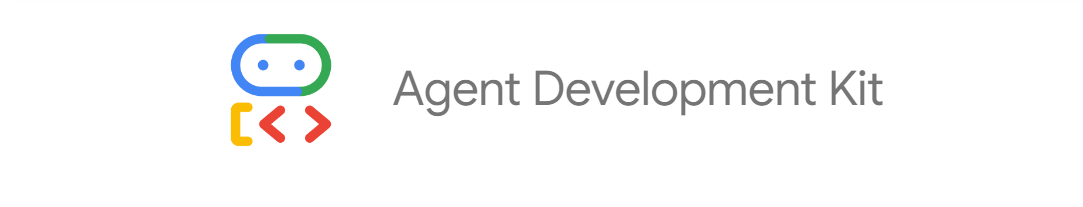

---
# Module 5: Configuring Models - Using Different Models with ADK

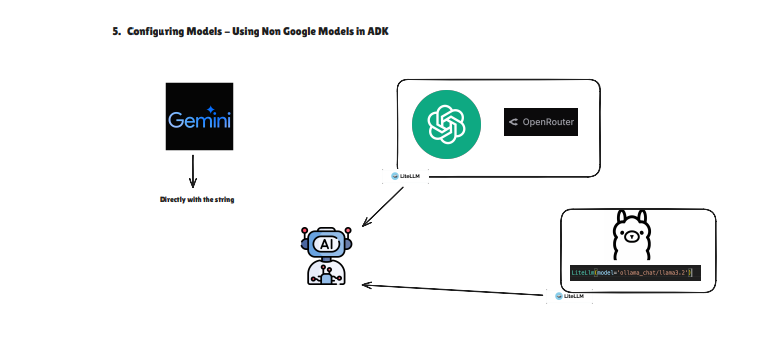

---

## Models & Authentication 👉 [Click Here](https://google.github.io/adk-docs/agents/models/)
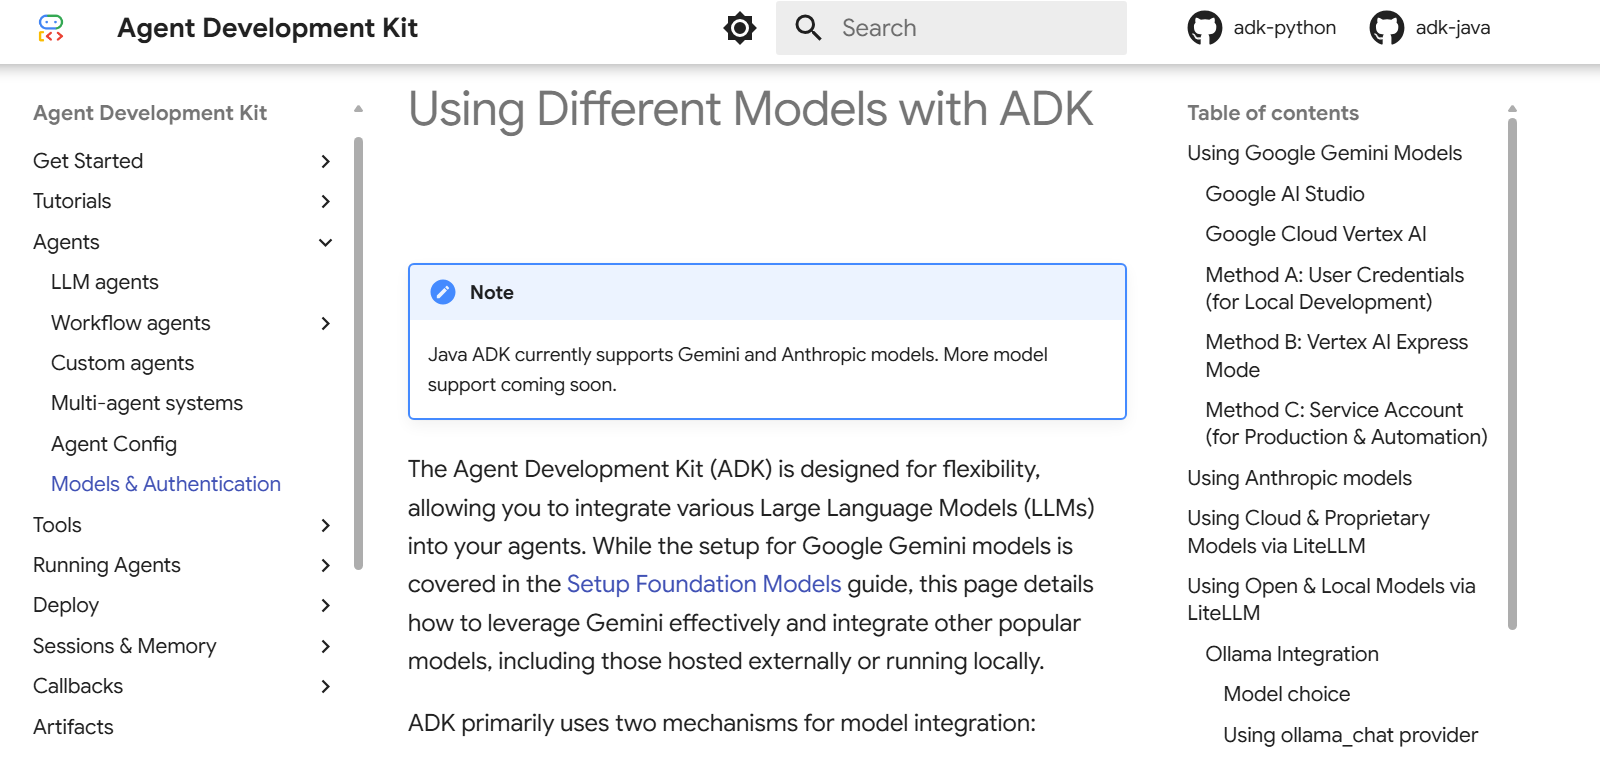 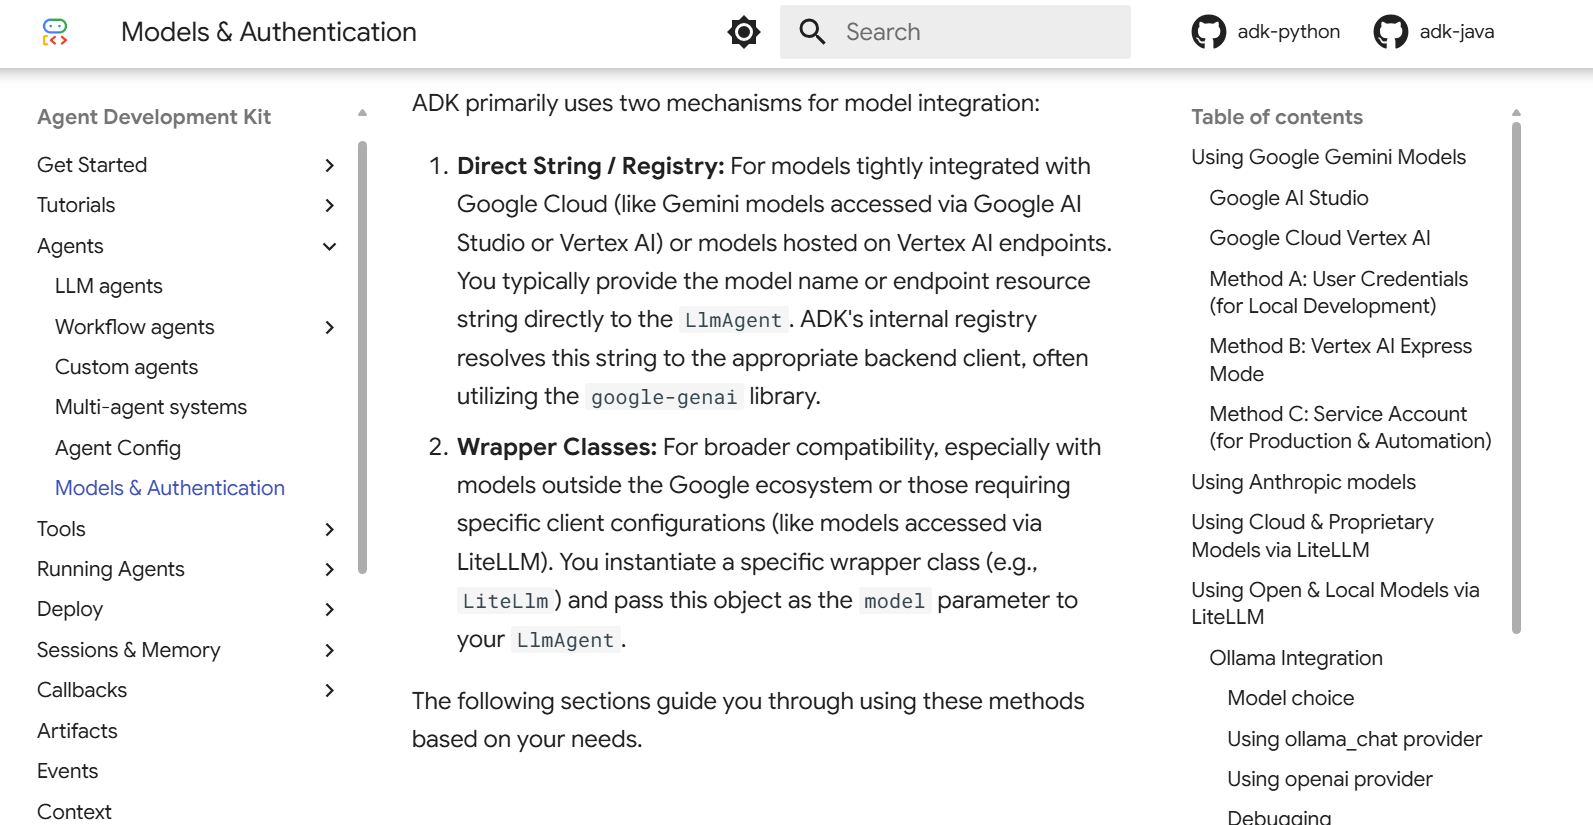

---
### Using Google Gemini Models
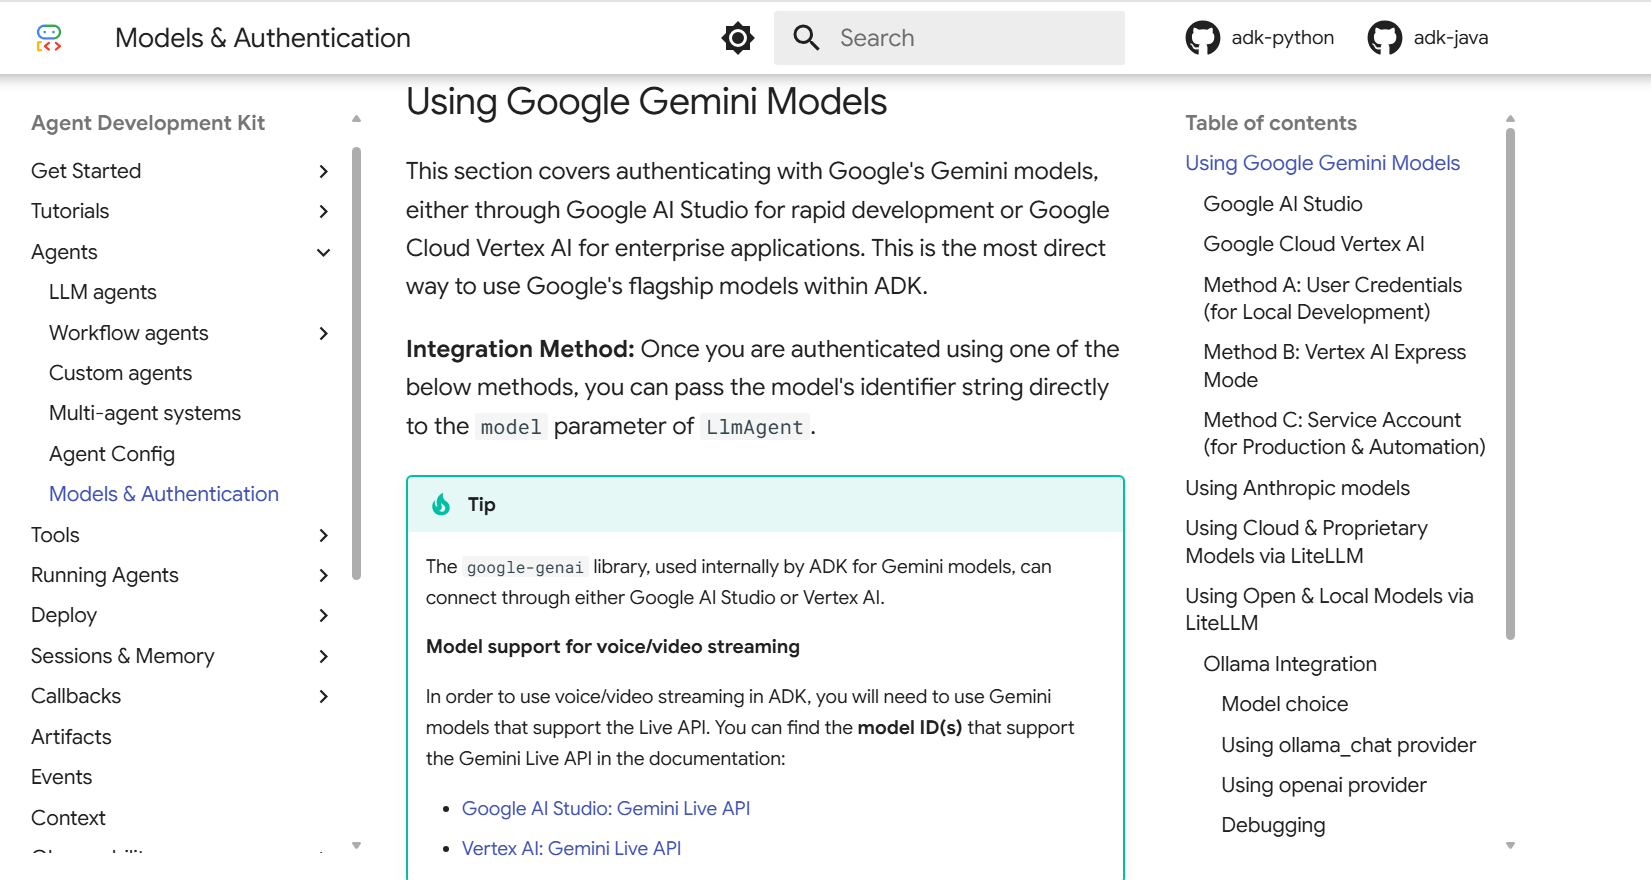

---

## `Click Here` 👉 [LiteLLM](https://www.litellm.ai/)
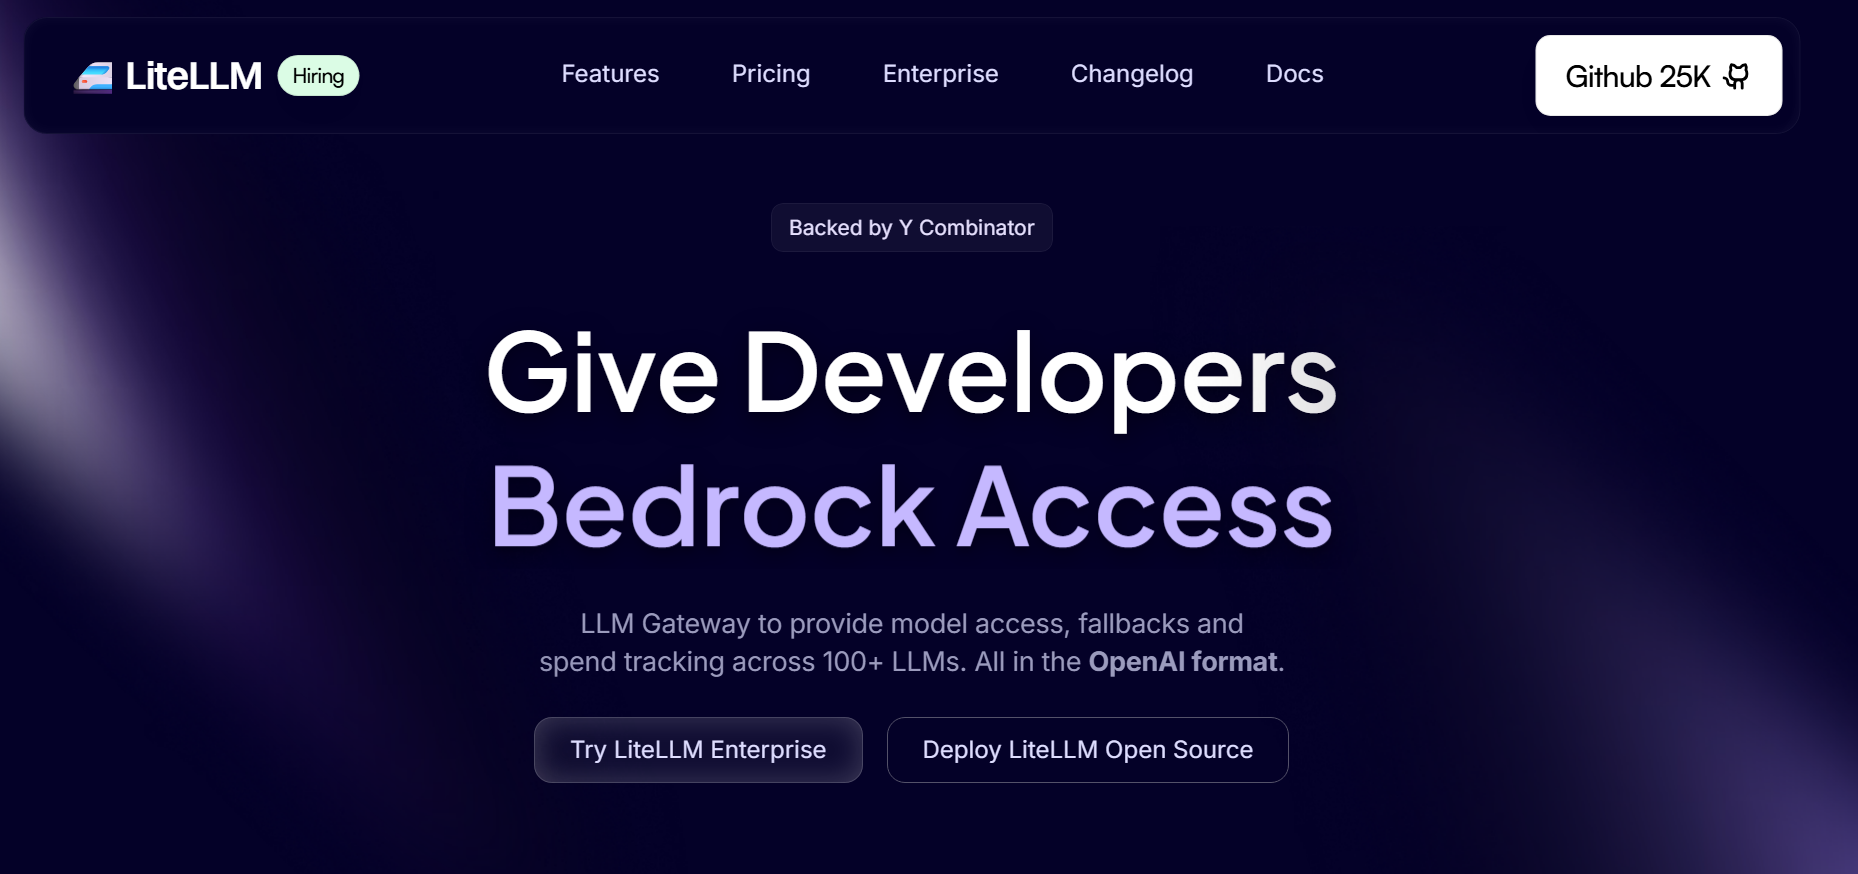 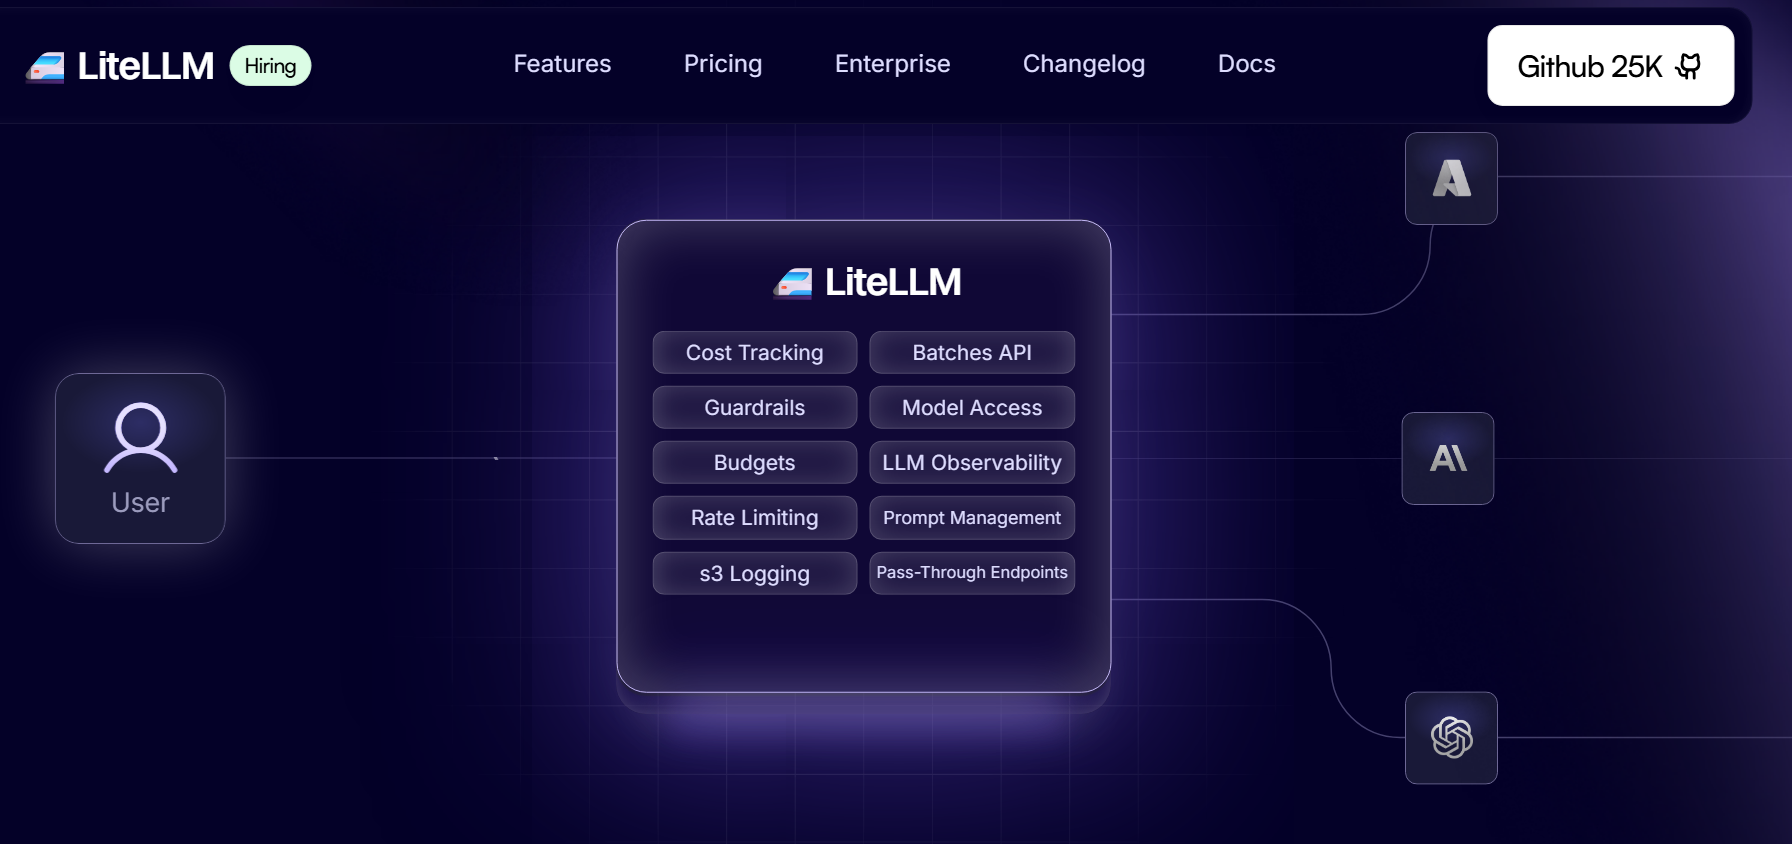

---

## `Click Here` 👉 [LiteLLM Docs](https://docs.litellm.ai/docs/)
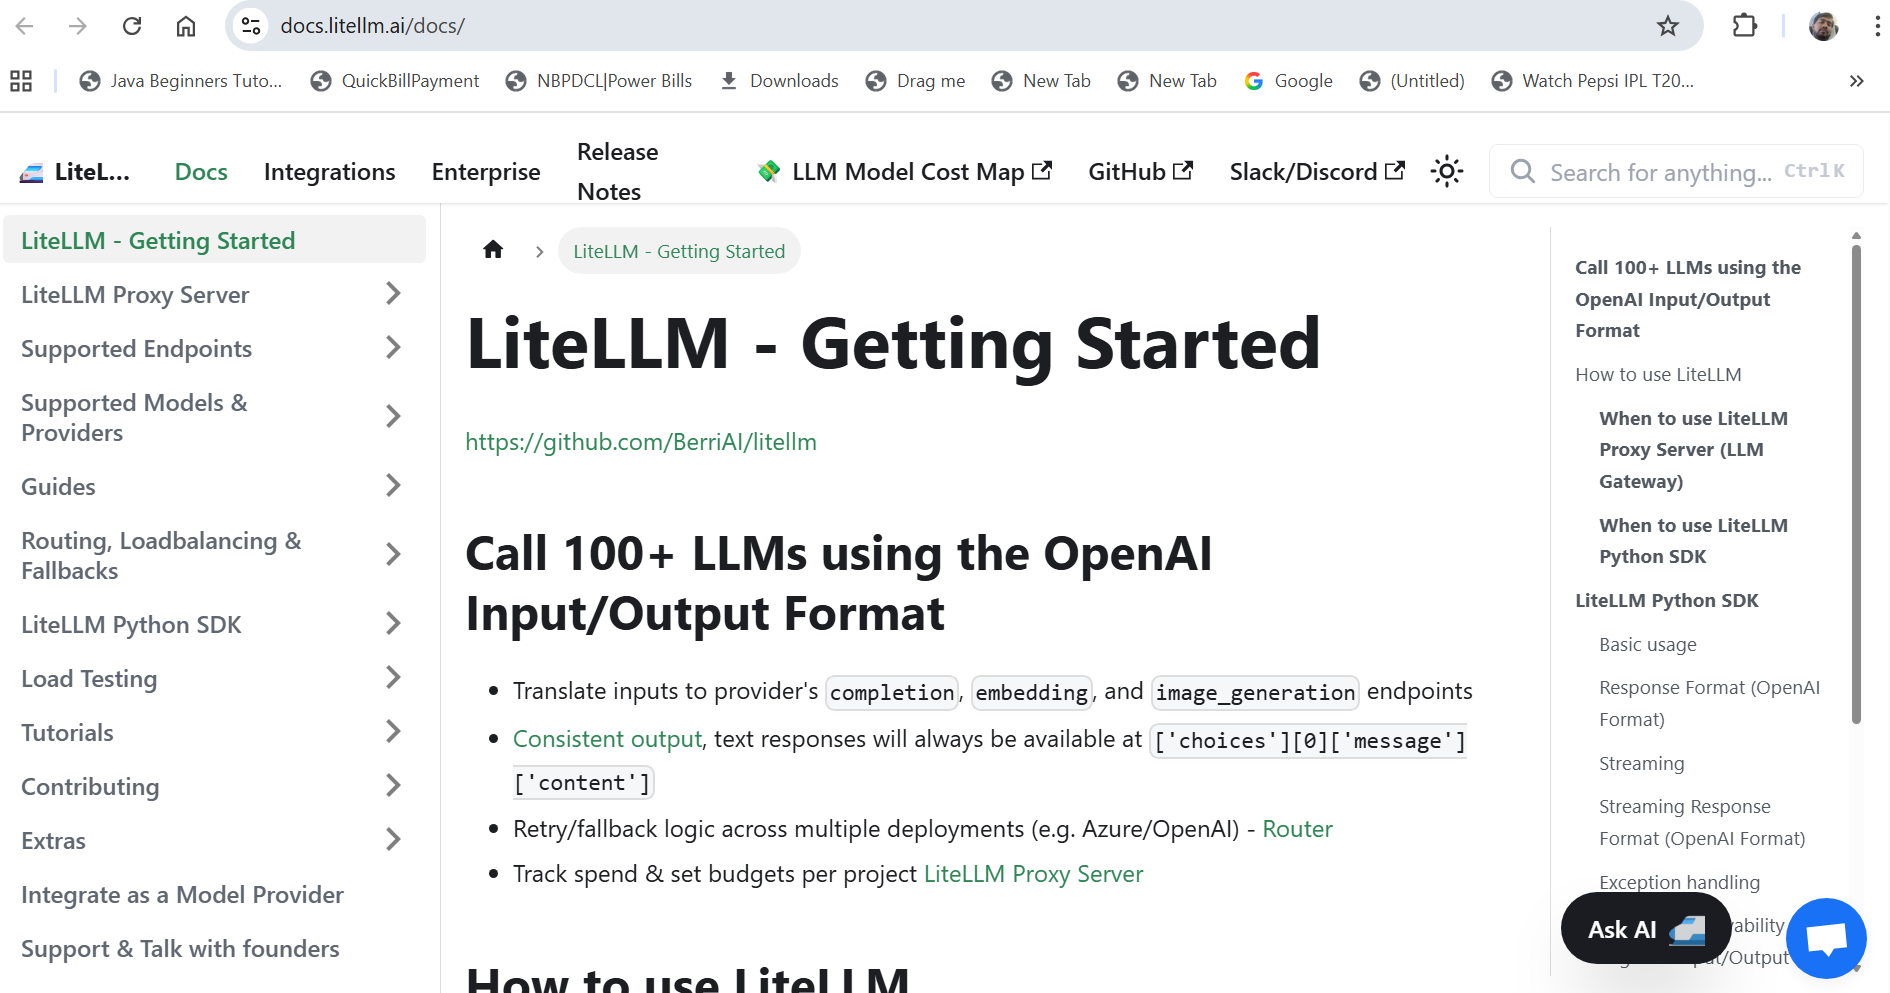 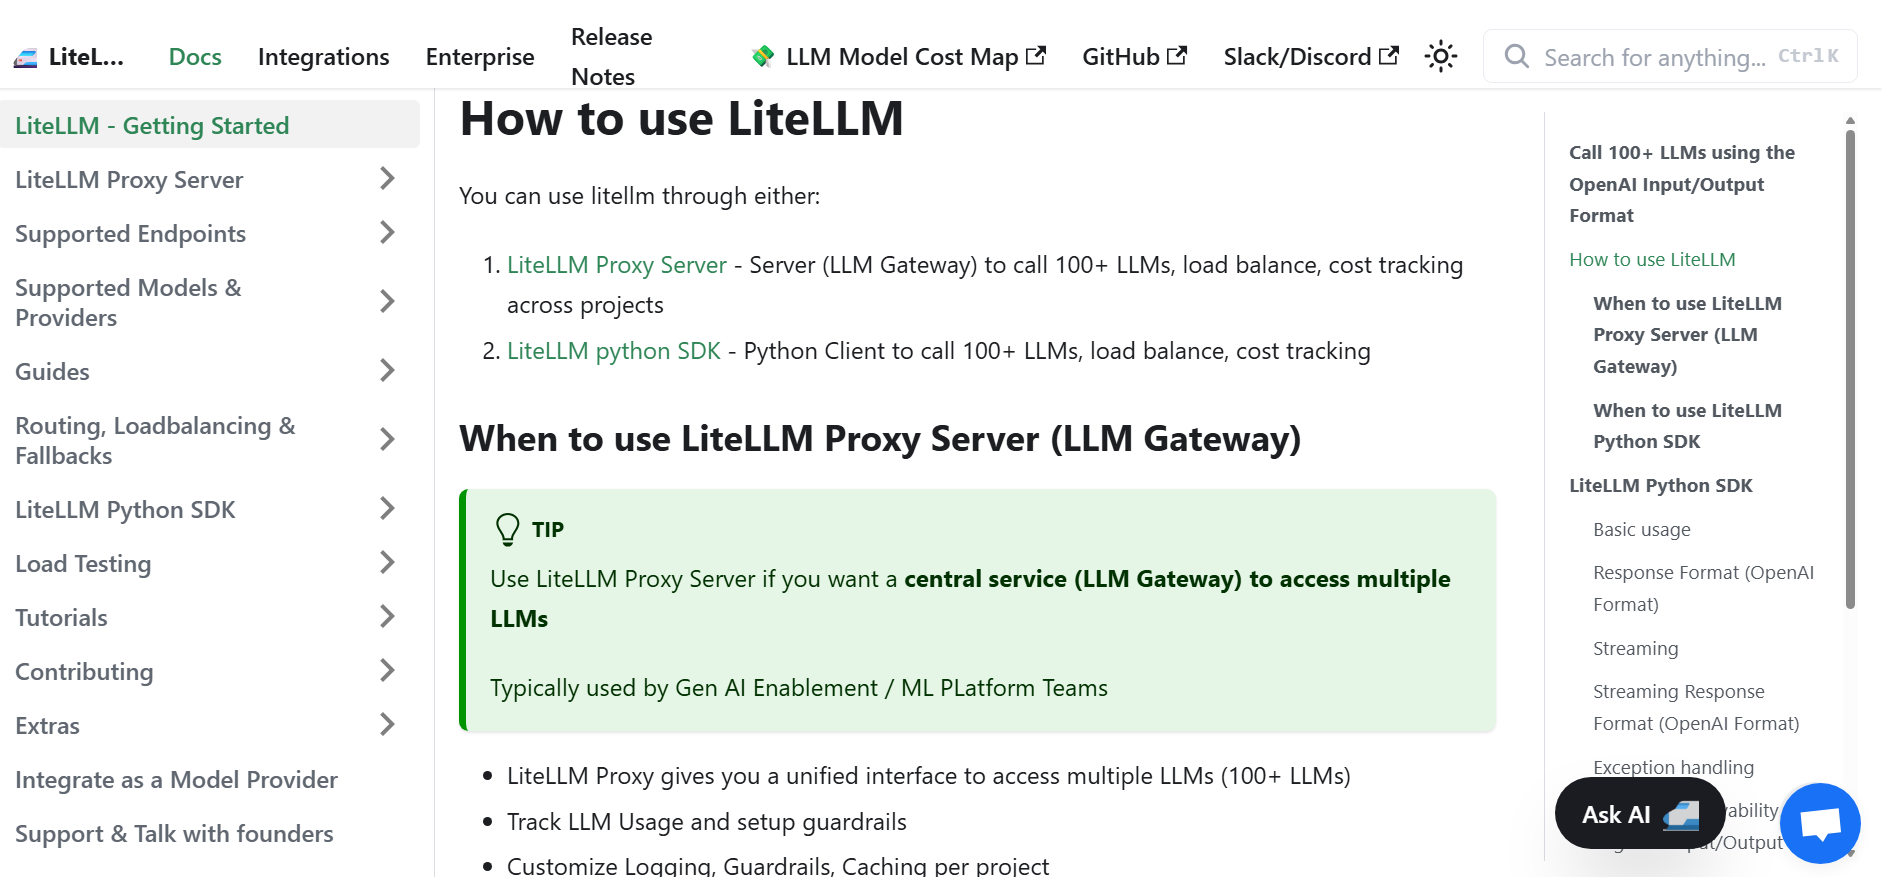 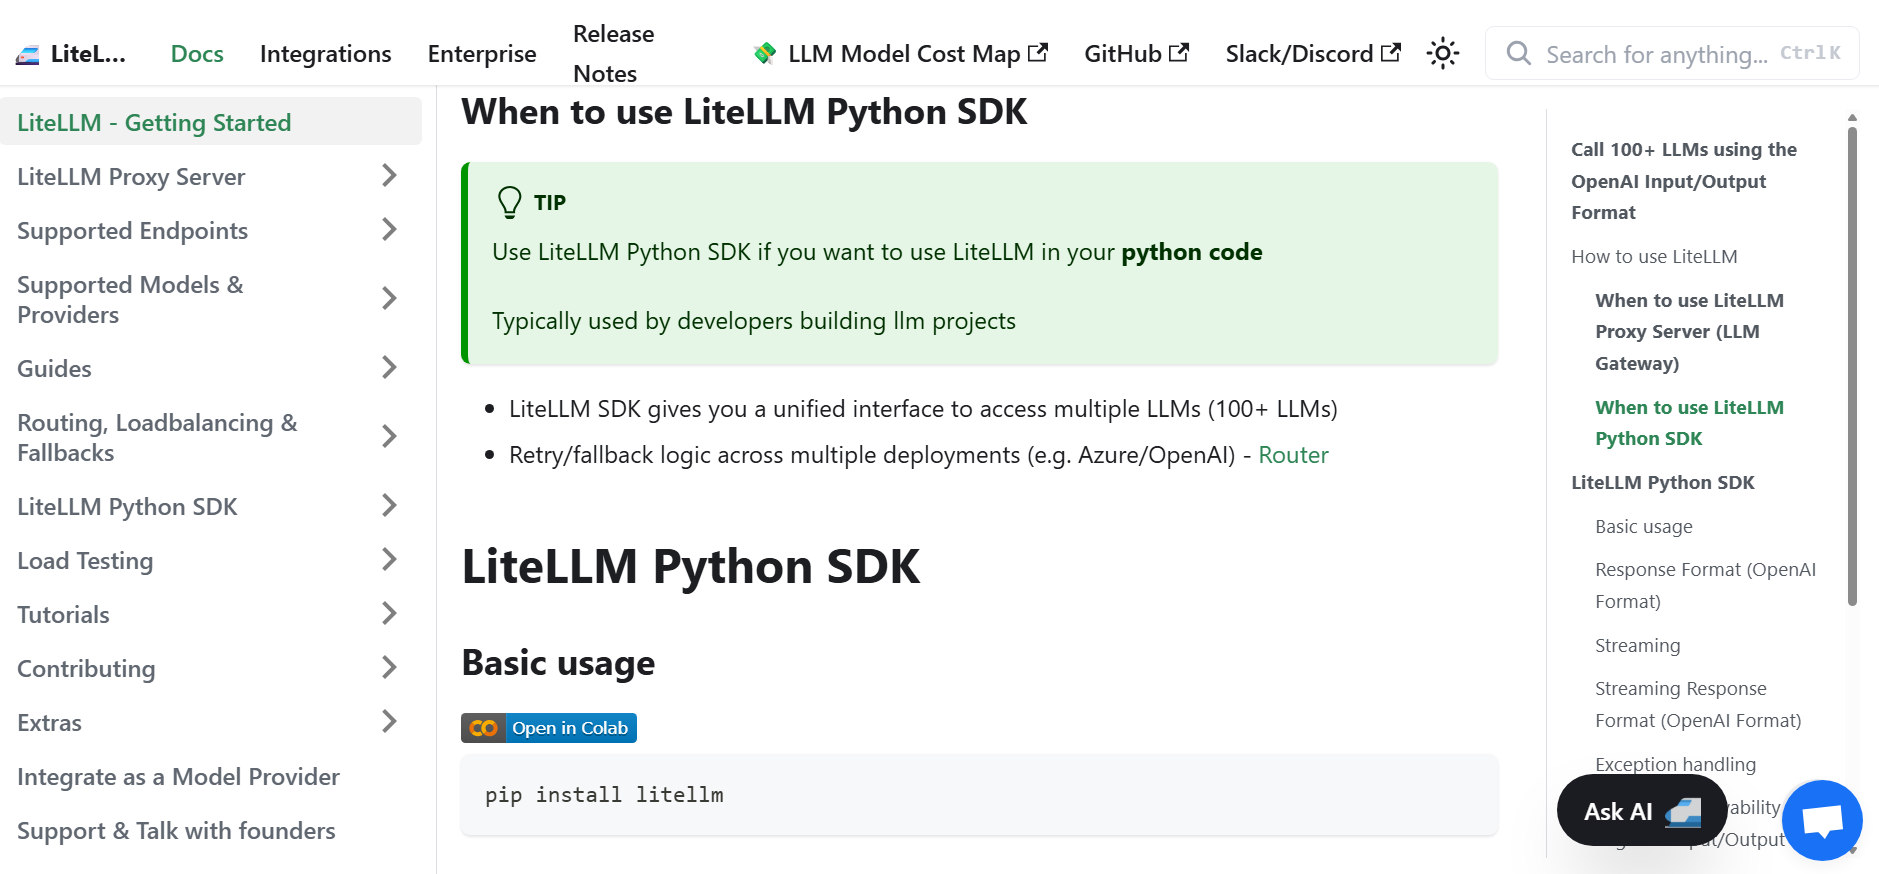

---

## `Click Here` 👉 [LiteLLM GitHub](https://github.com/BerriAI/litellm)
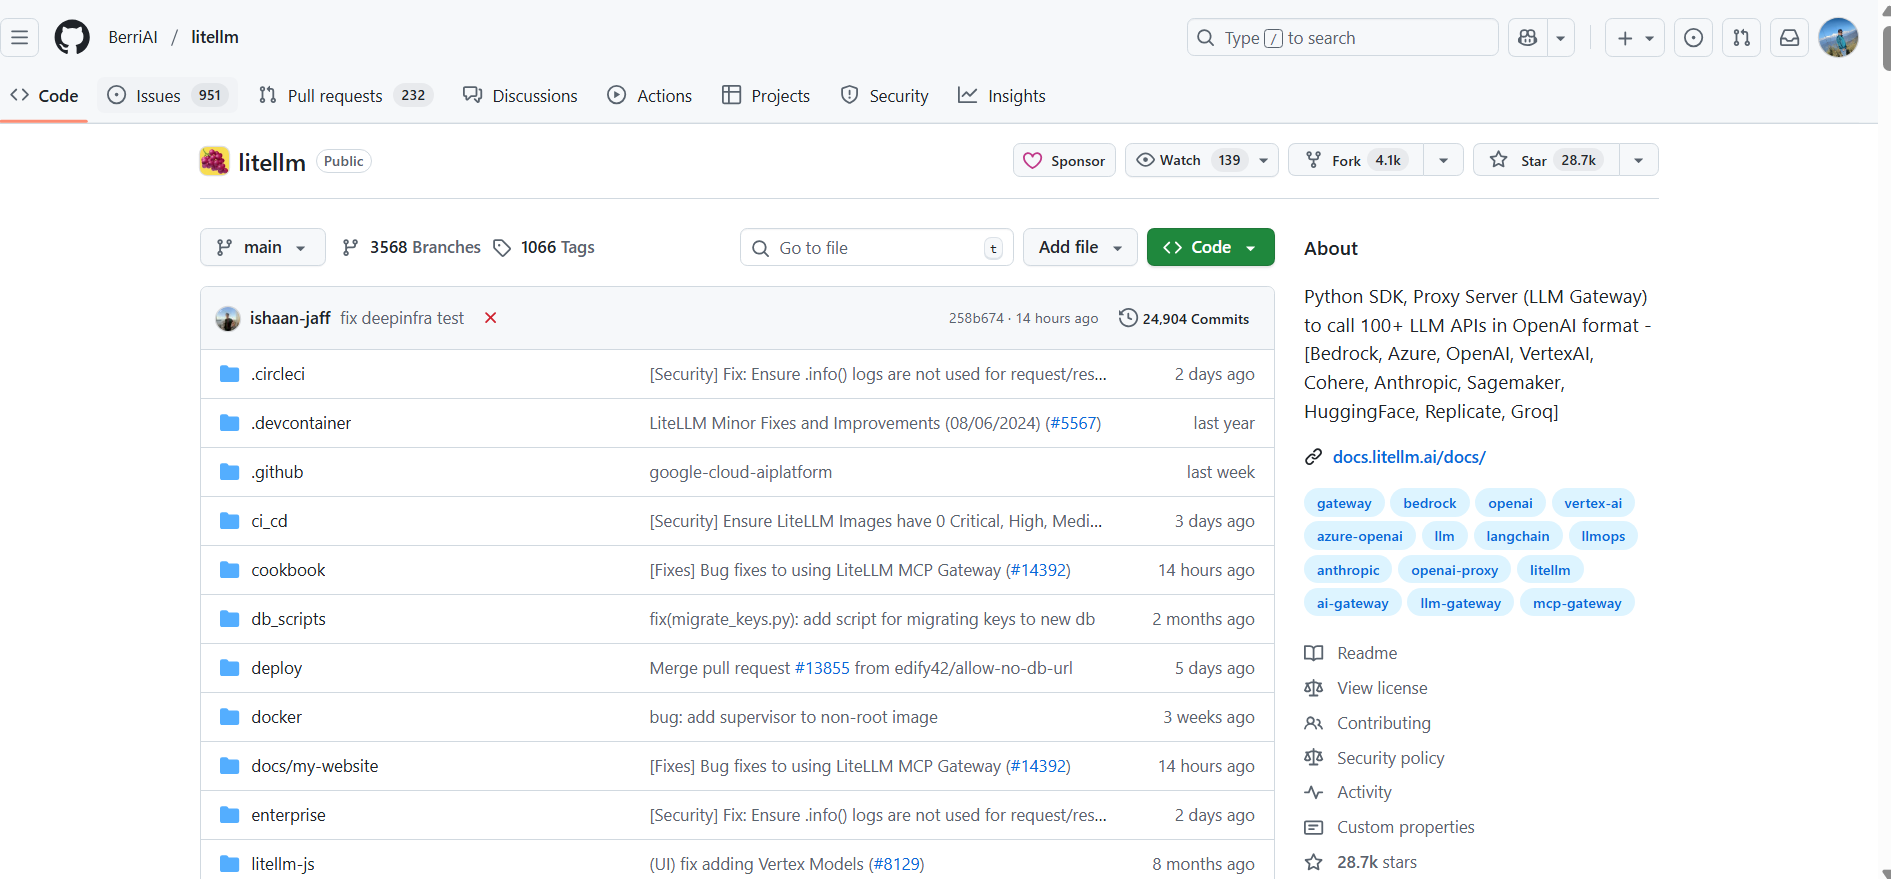

---

## `Click Here` 👉 [OpenRouter](https://openrouter.ai/)
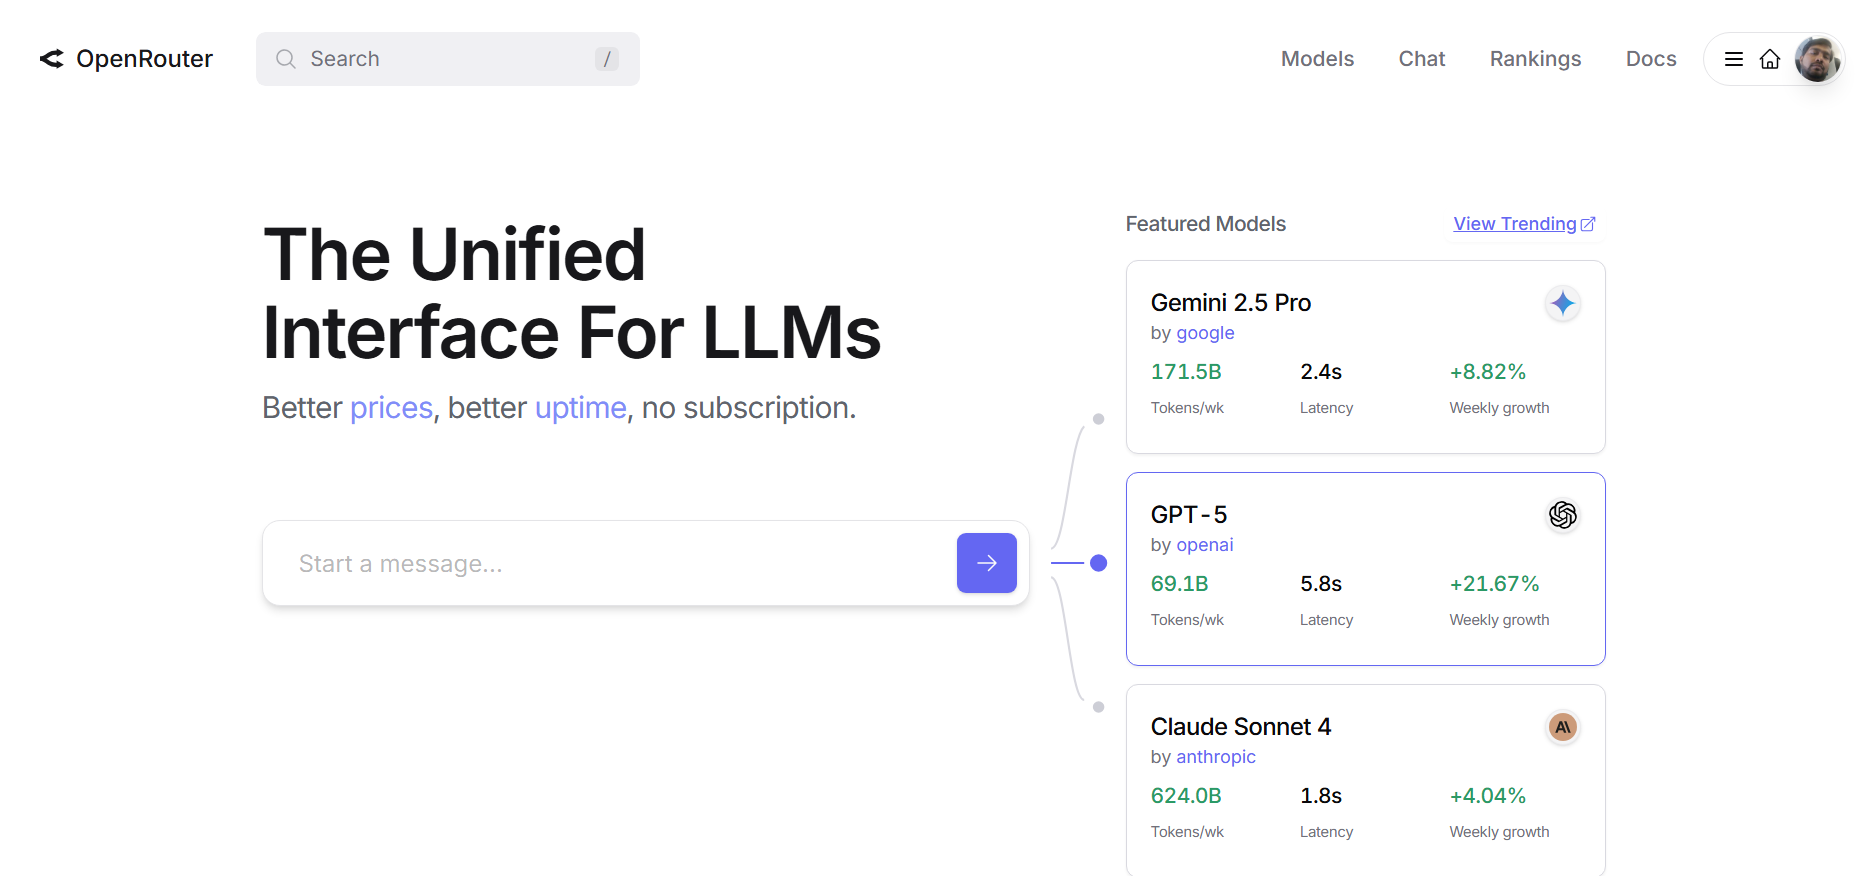 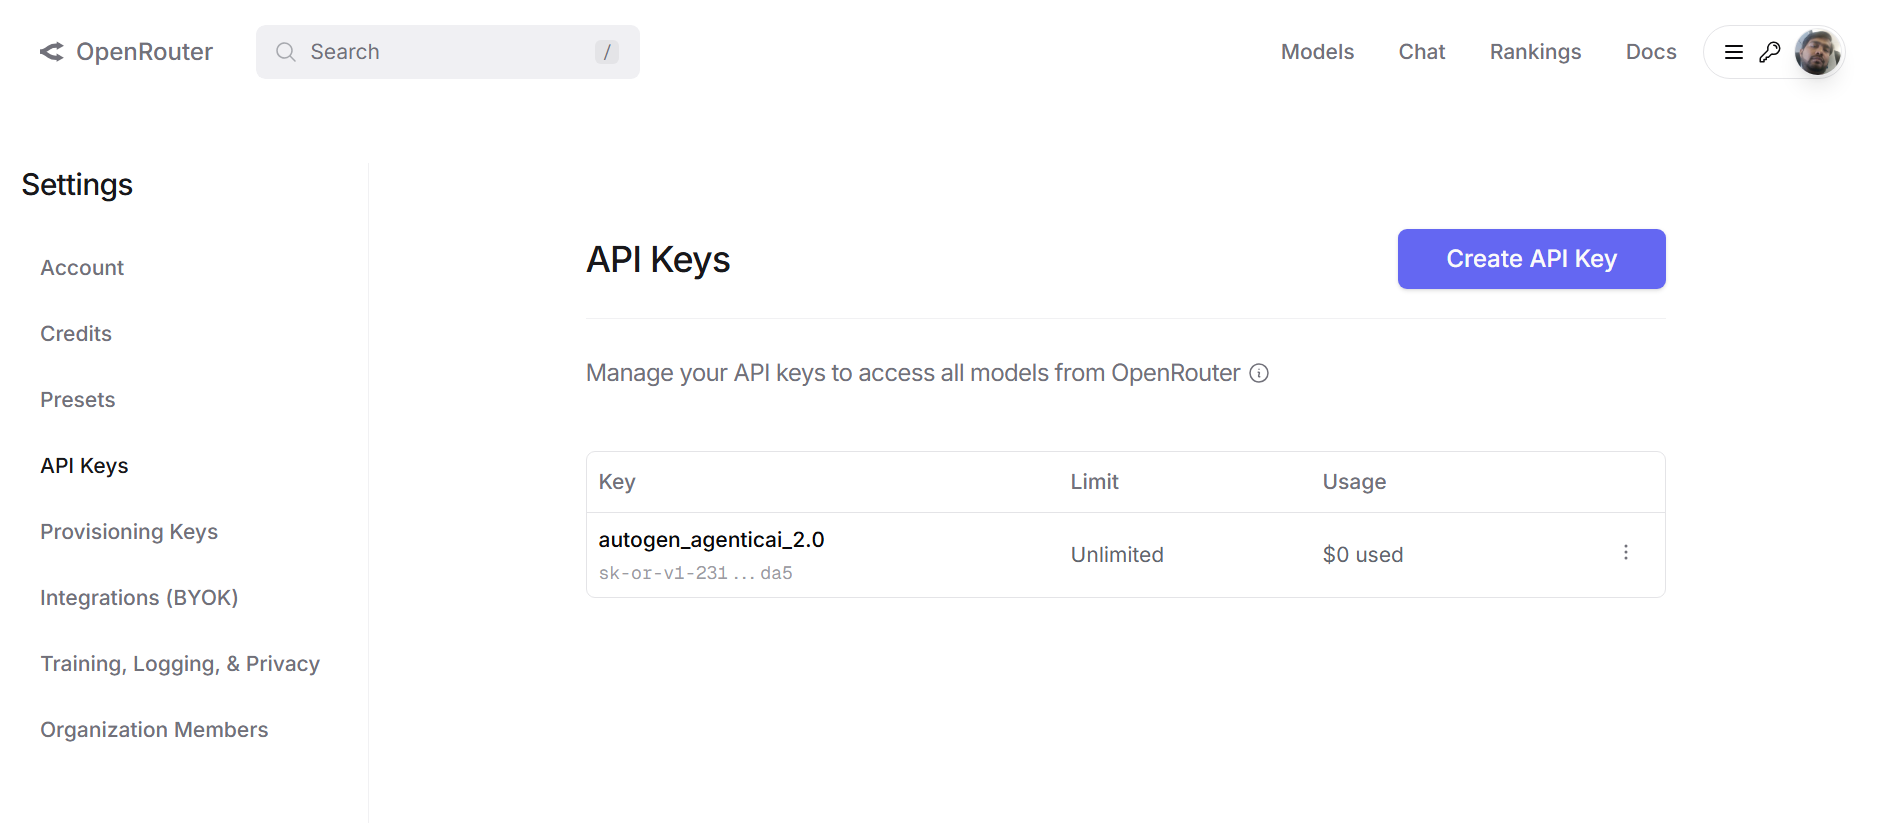
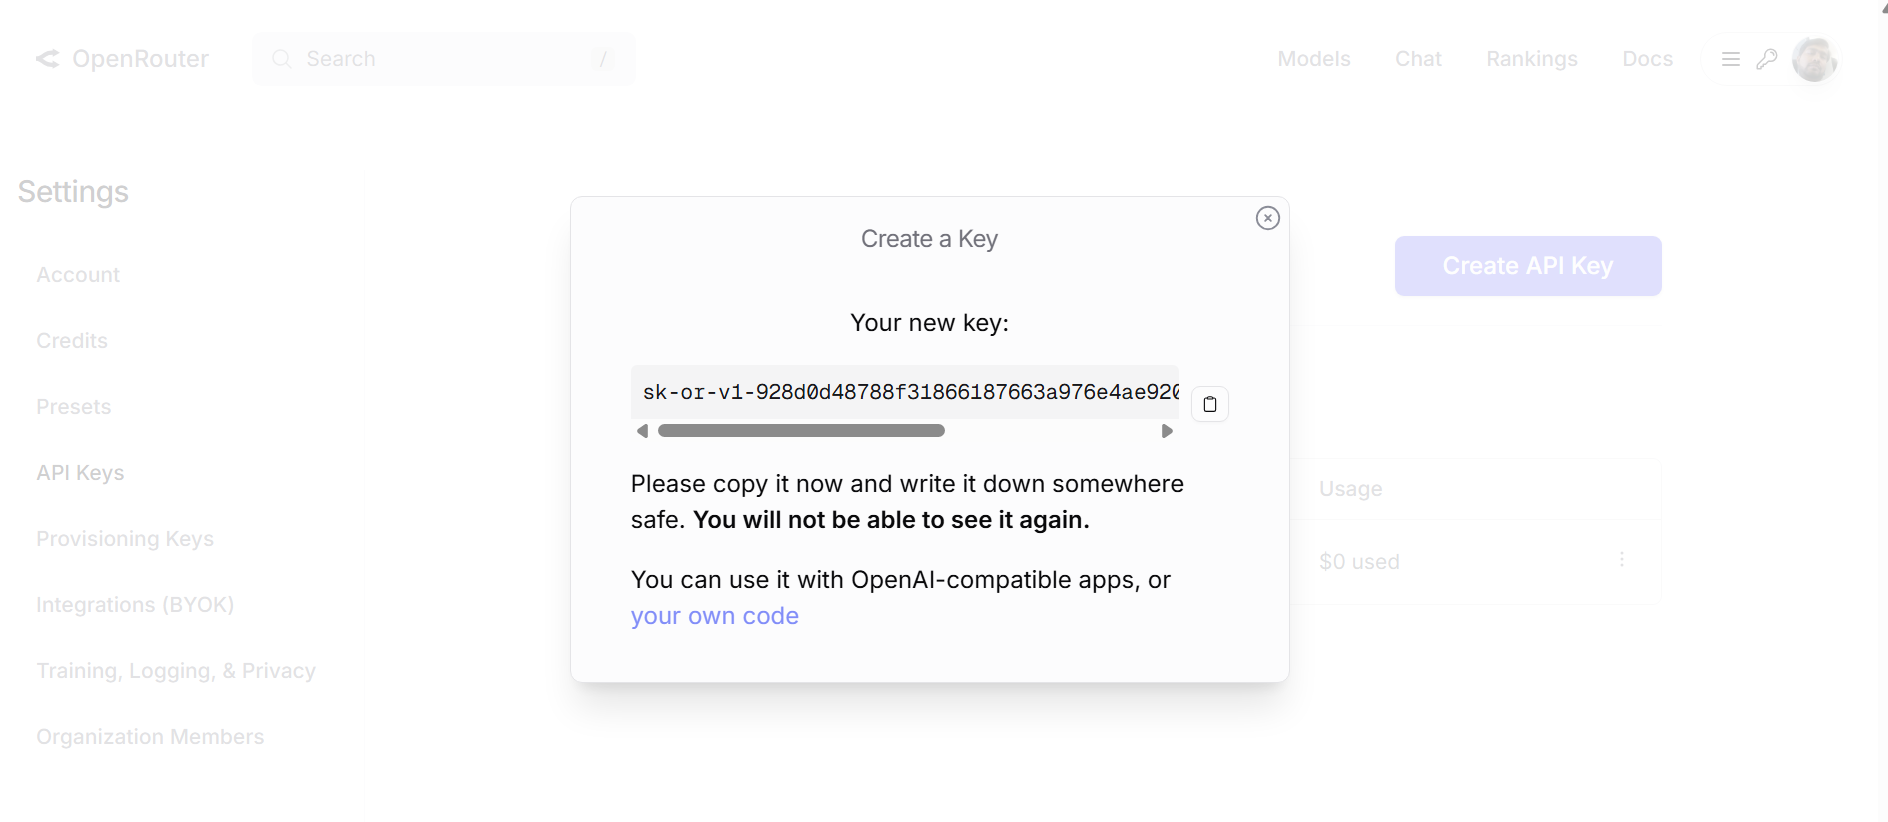

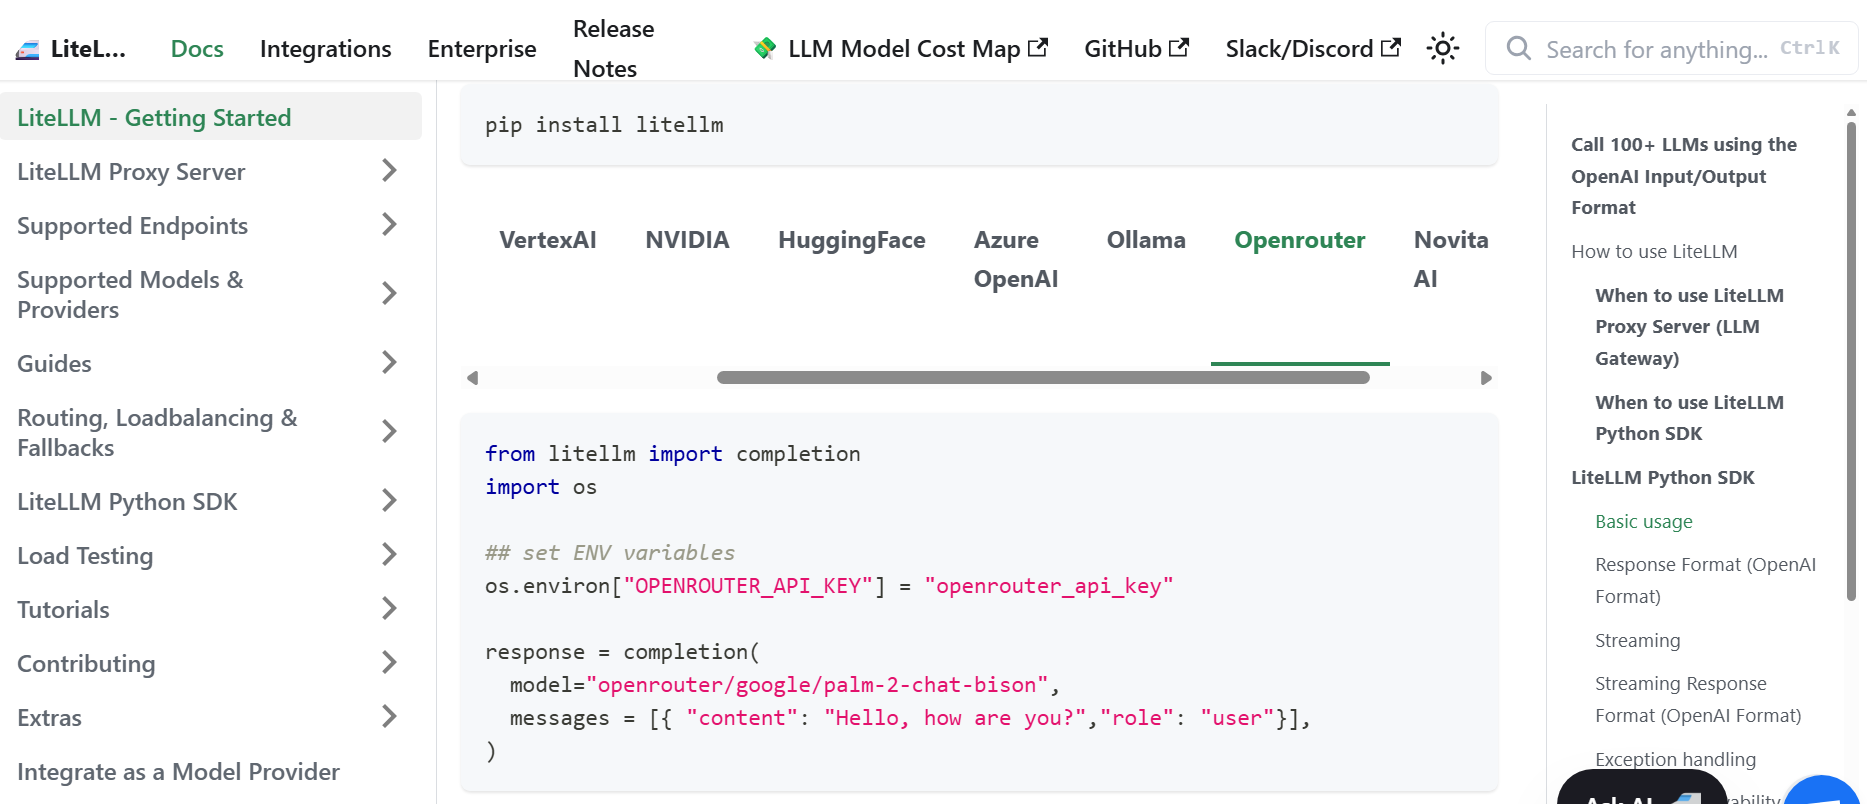

### `test_openrouter.py`
```Python
from openai import OpenAI

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key="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",
)

completion = client.chat.completions.create(
  extra_headers={
    "HTTP-Referer": "<YOUR_SITE_URL>", # Optional. Site URL for rankings on openrouter.ai.
    "X-Title": "<YOUR_SITE_NAME>", # Optional. Site title for rankings on openrouter.ai.
  },
  extra_body={},
  model="deepseek/deepseek-chat-v3-0324:free",
  messages=[
    {
      "role": "user",
      "content": "What is the meaning of life?"
    }
  ]
)
print(completion.choices[0].message.content)
```
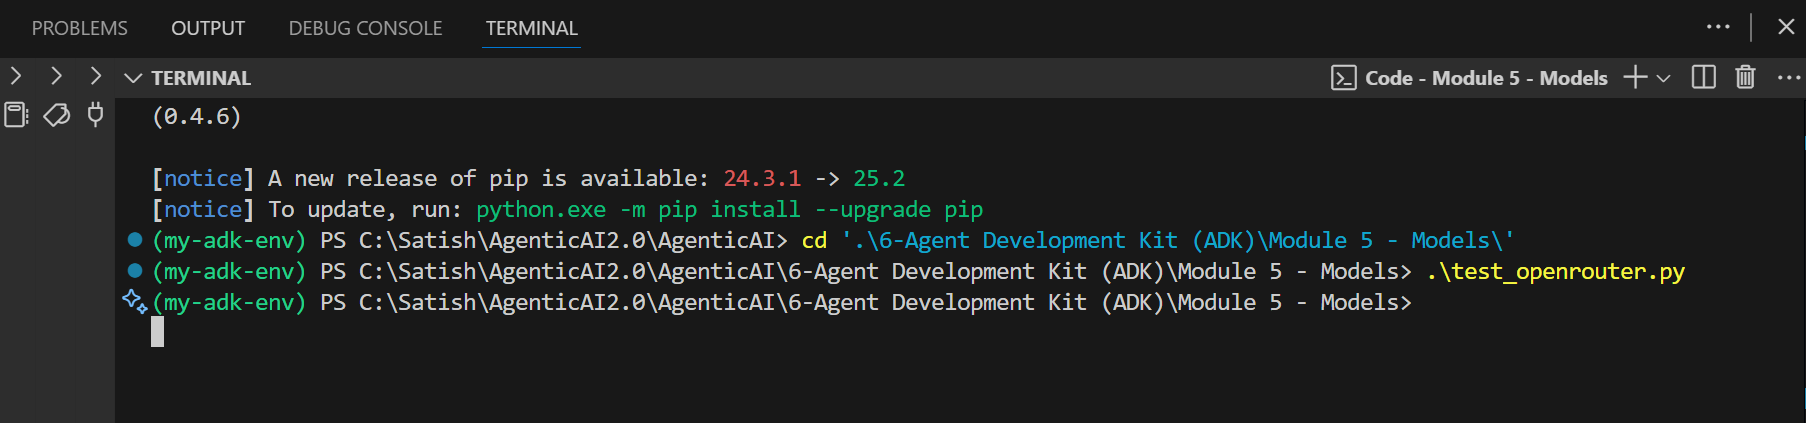 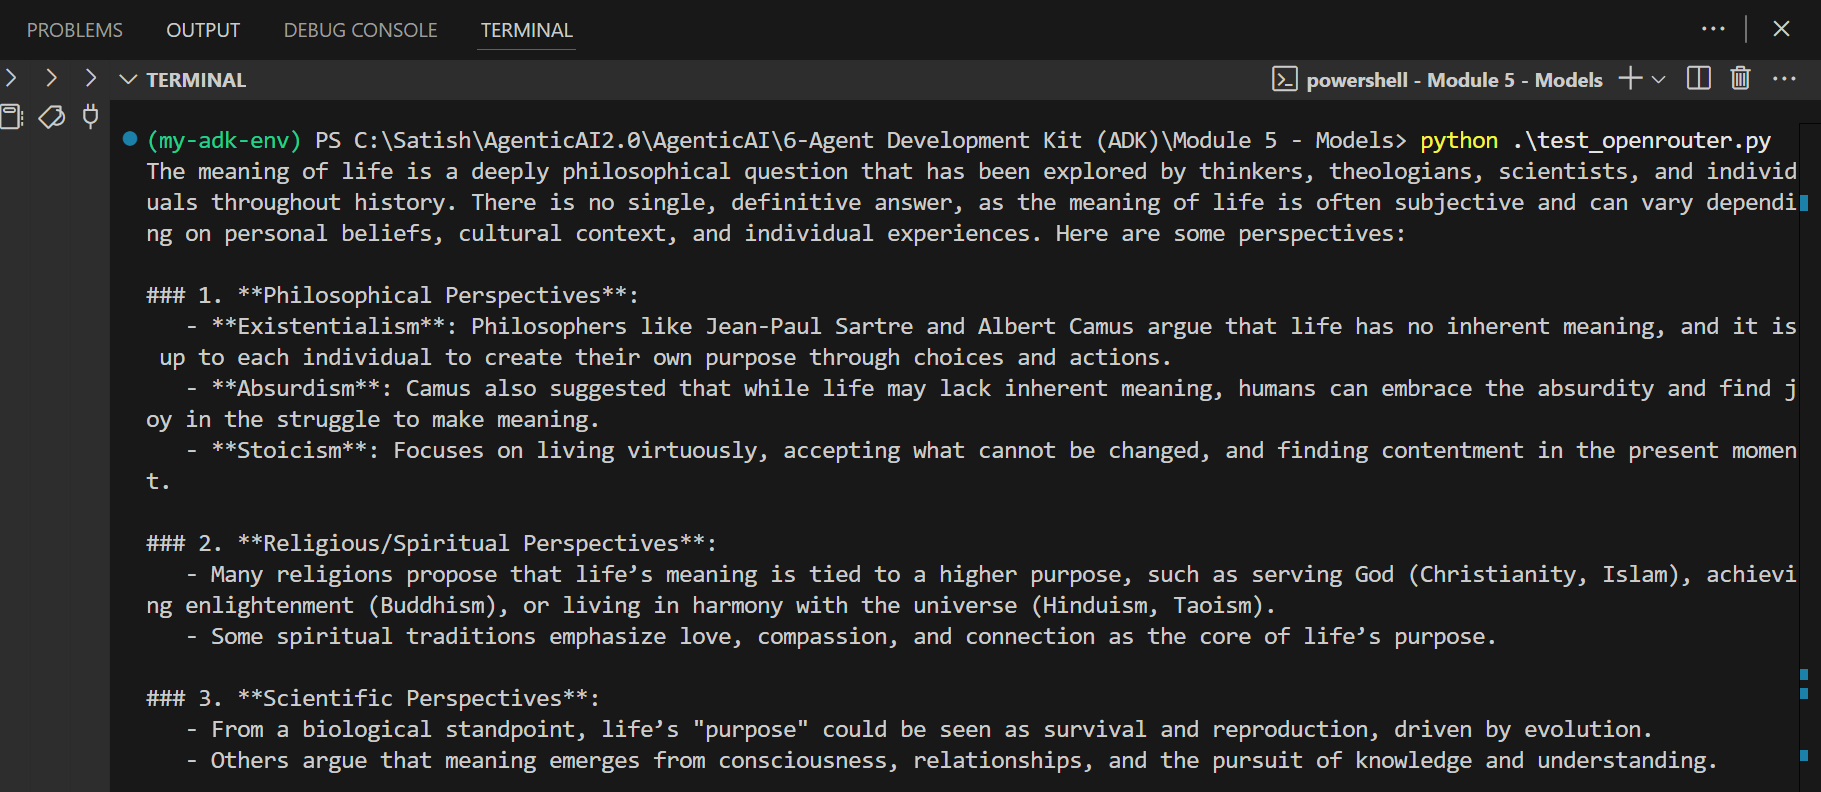
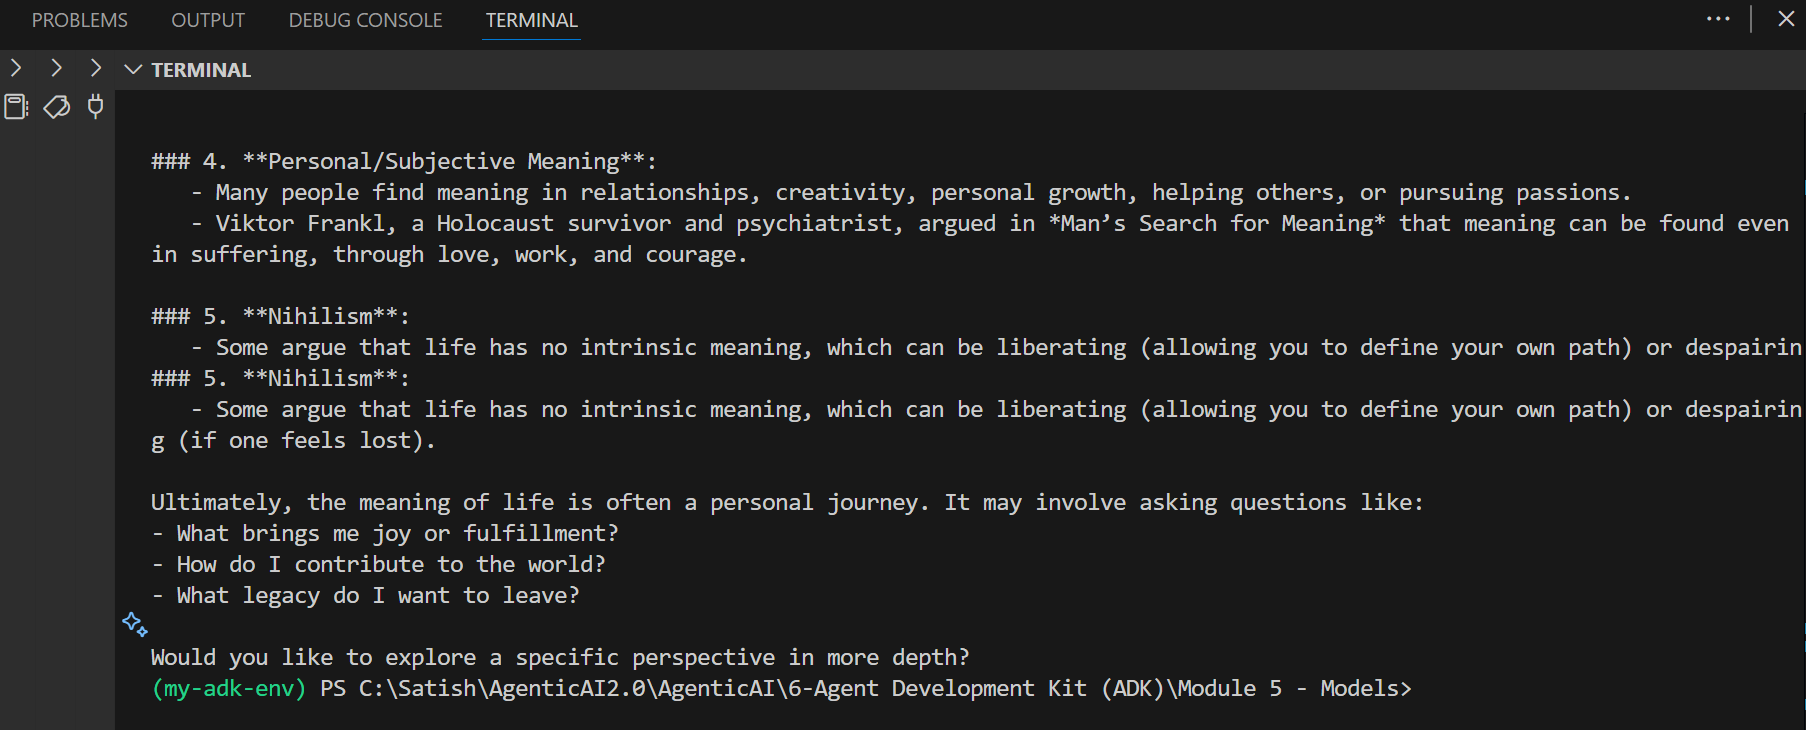

---

## `test_ollama.py`
```Python
import requests

headers = {
    'Content-Type': 'application/json',
}

data = {
    "model": "llama3.2",  # Ensure this is the correct model name for Llama 3.2
    "messages": [
        {"role": "user", "content": "Hello Ollama, are you running?"}
    ]
}

# Replace 'localhost' with your actual Ollama server address if different
response = requests.post('http://localhost:11434/v1/chat/completions', headers=headers, json=data)

if response.status_code == 200:
    print("Success! Llama 3.2 is running on Ollama.")
    print("Response:", response.json())
else:
    print("Error! Status code:", response.status_code)
    print("Details:", response.text)
```
<hr>

## OpenRouter Agent
```Python
from google.adk.agents import Agent
import dotenv
from google.adk.models.lite_llm import LiteLlm
import os

dotenv.load_dotenv()
openrouter_model = LiteLlm(model='openrouter/deepseek/deepseek-chat-v3-0324:free',
                           api_key=os.getenv('OPENROUTER_API_KEY'))

root_agent = Agent(
    model=openrouter_model,
    name='root_agent',
    description='A helpful assistant for user questions.',
    instruction='Answer user questions to the best of your knowledge',
)
```

## `http://127.0.0.1:8000`
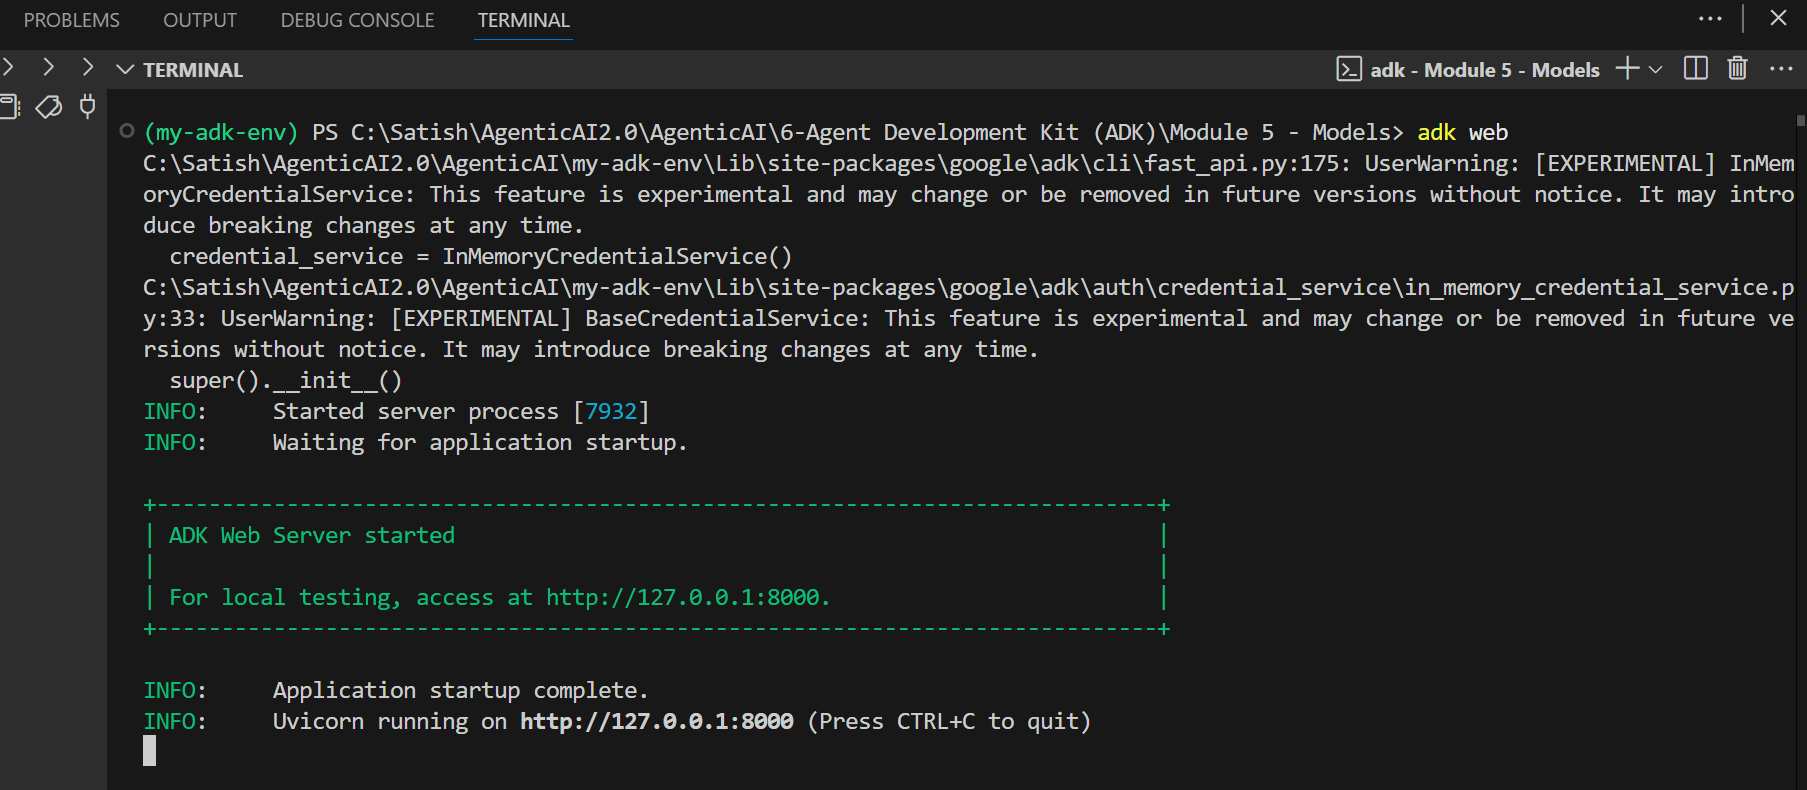  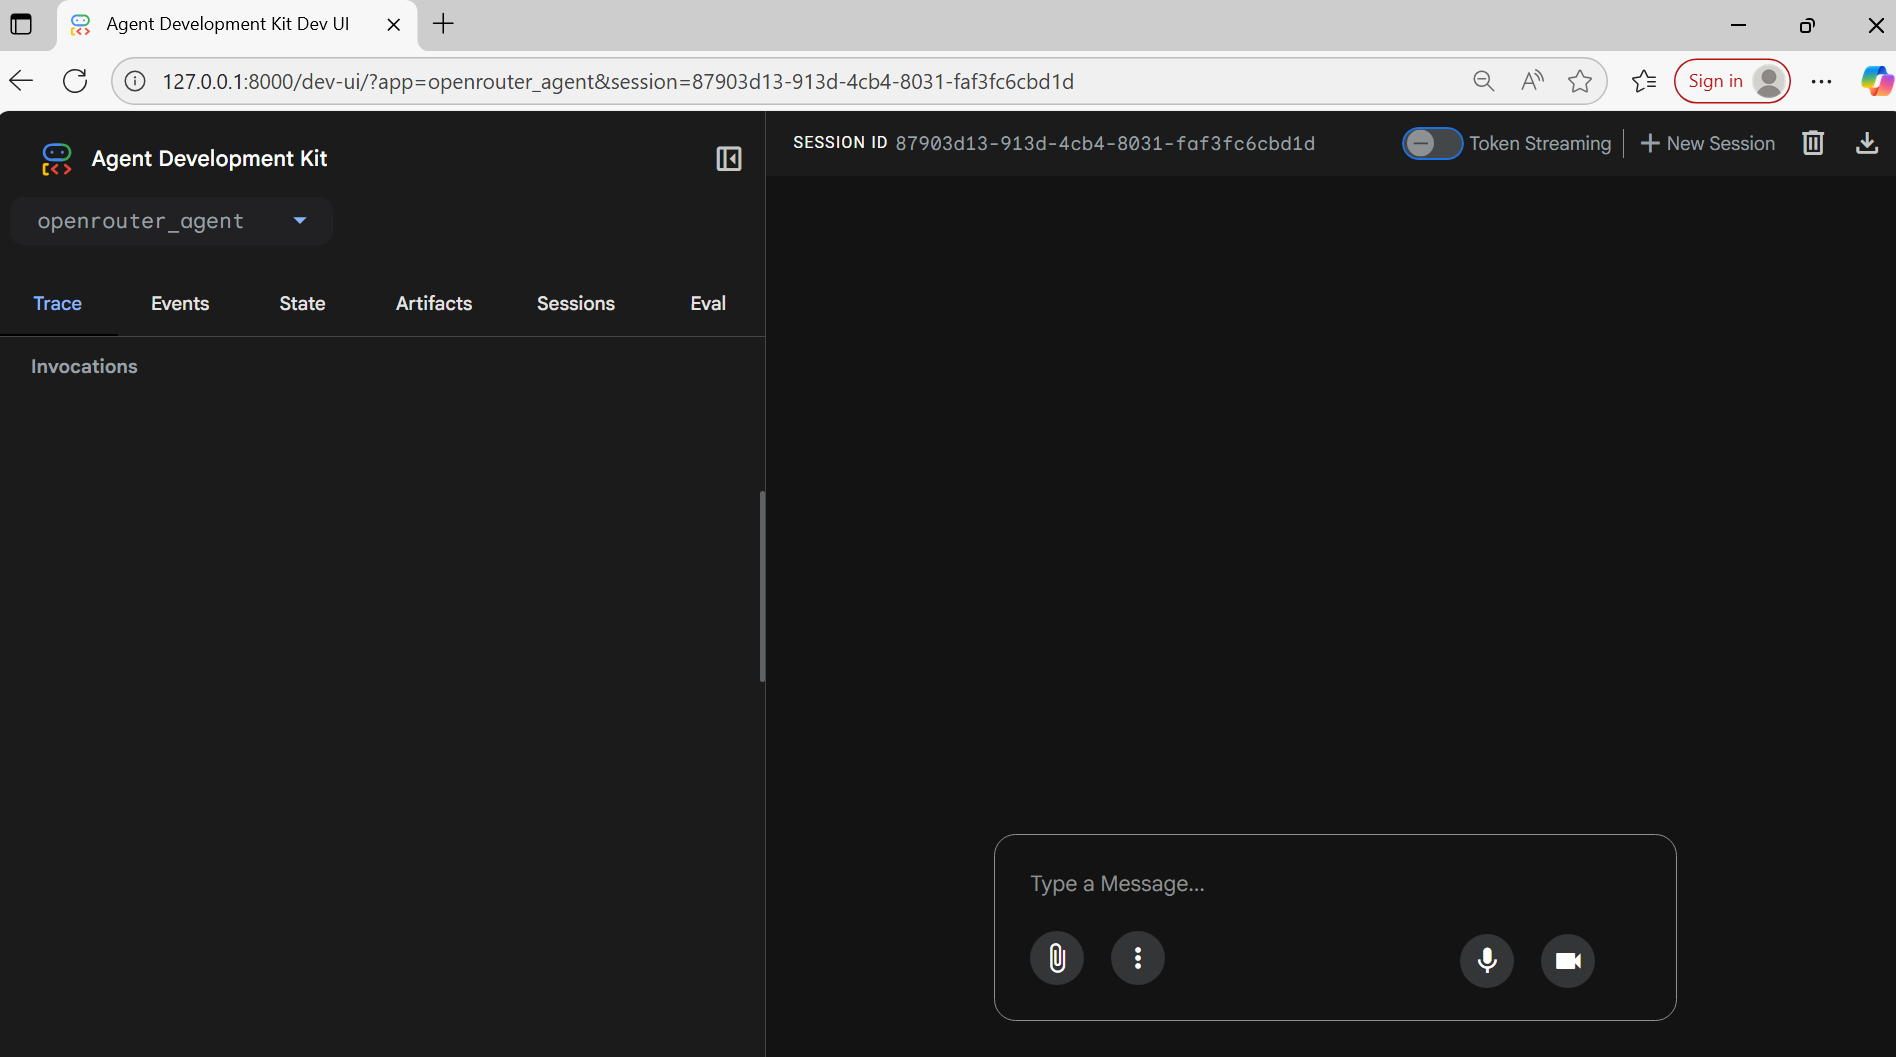 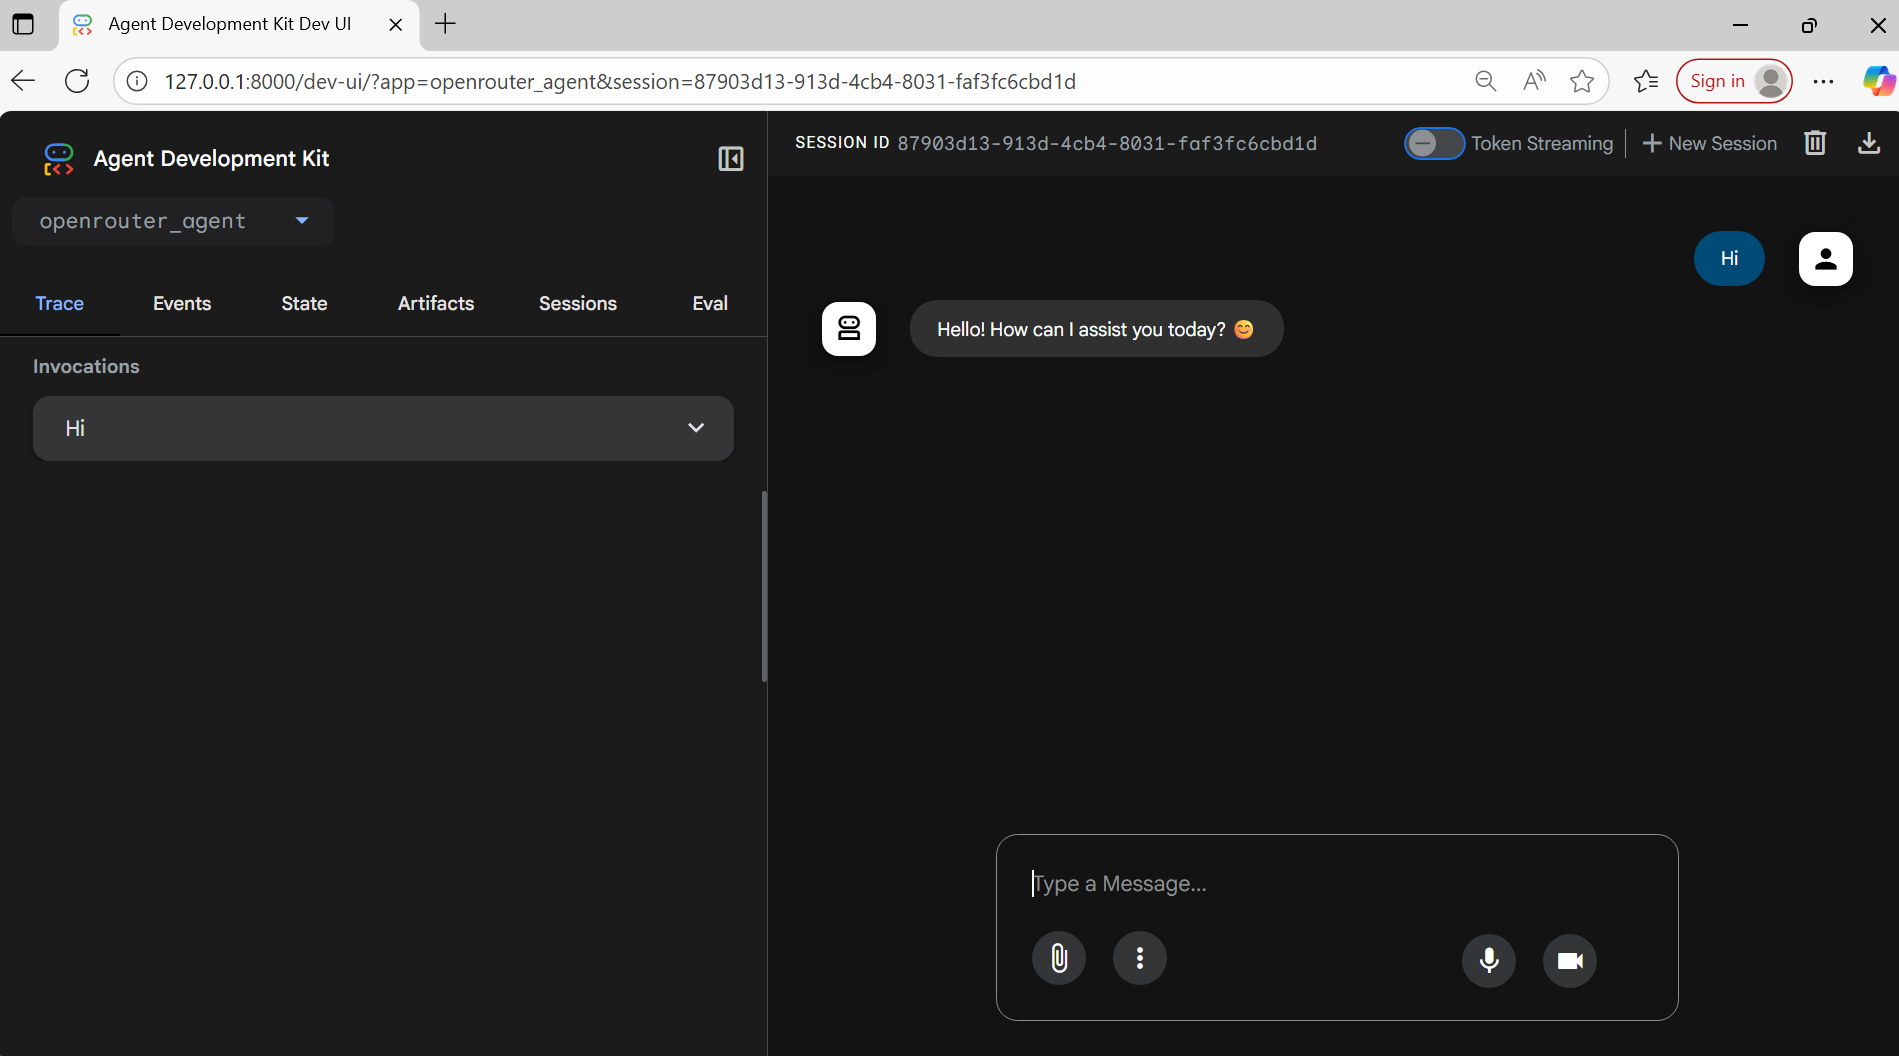 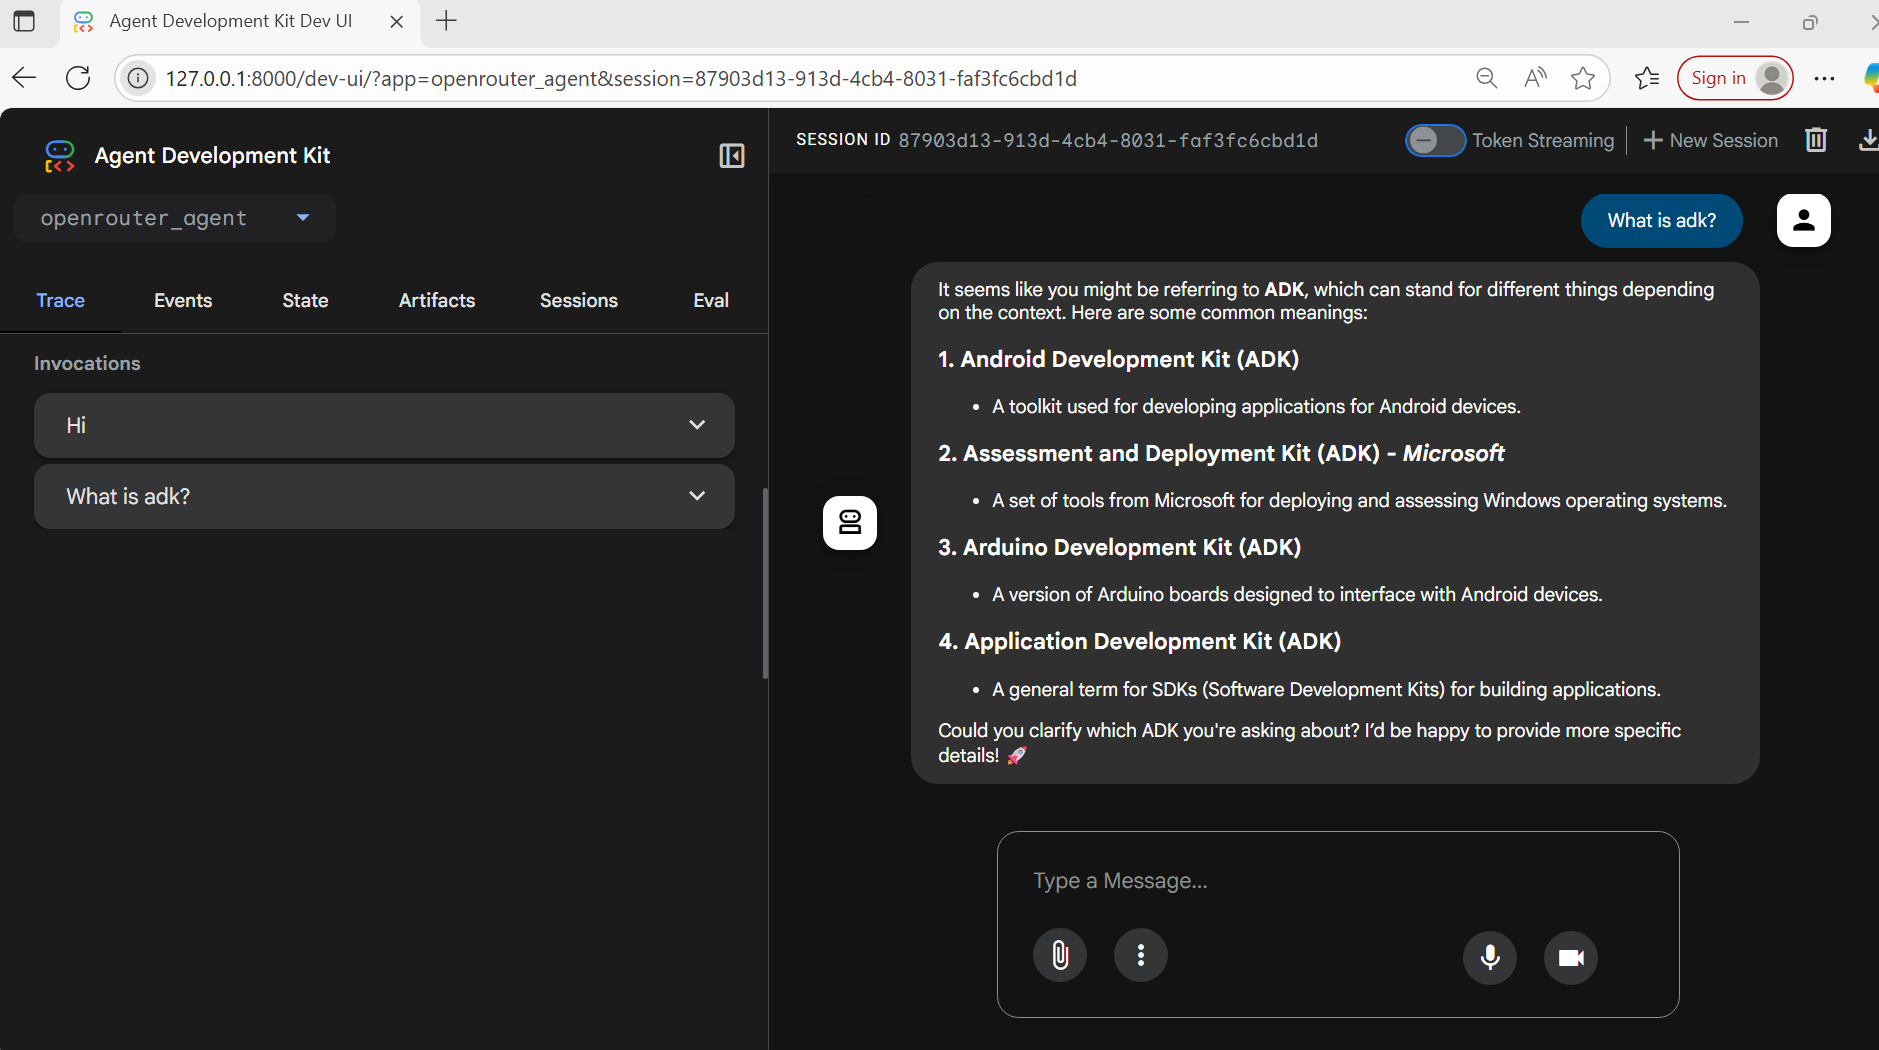 
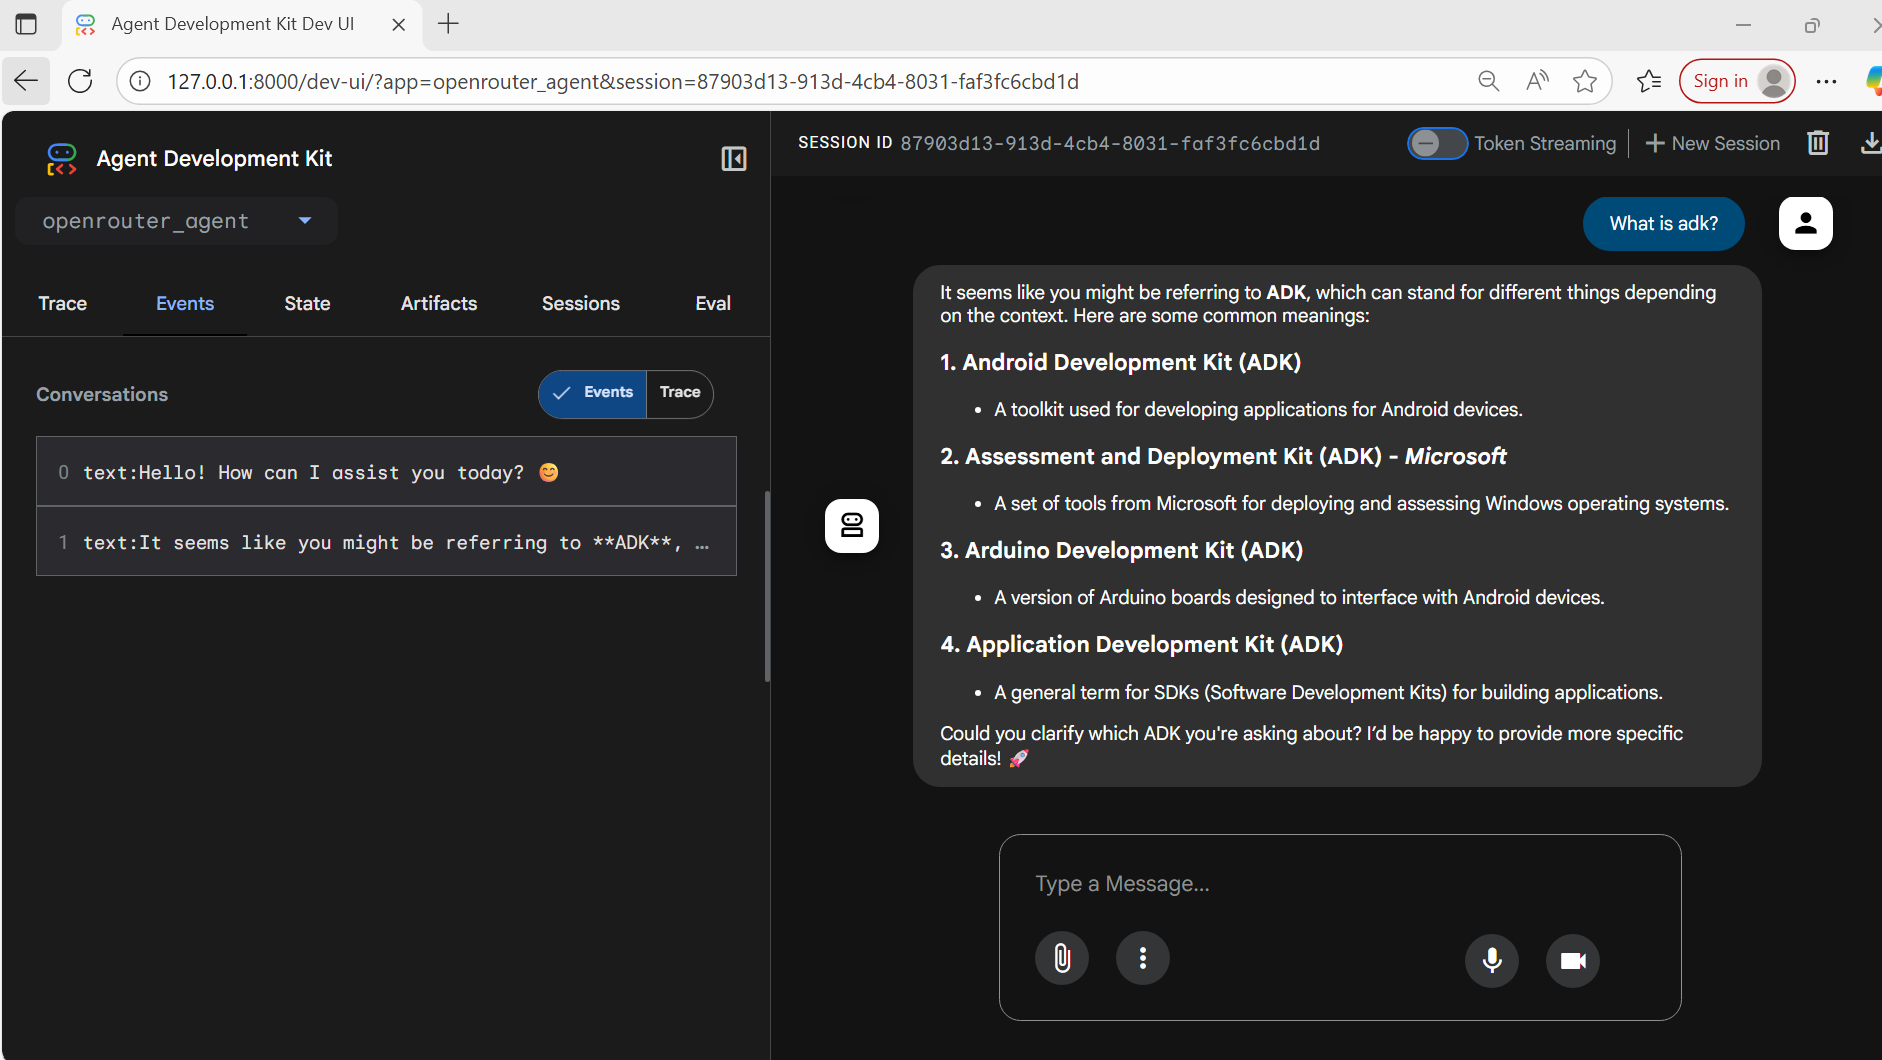 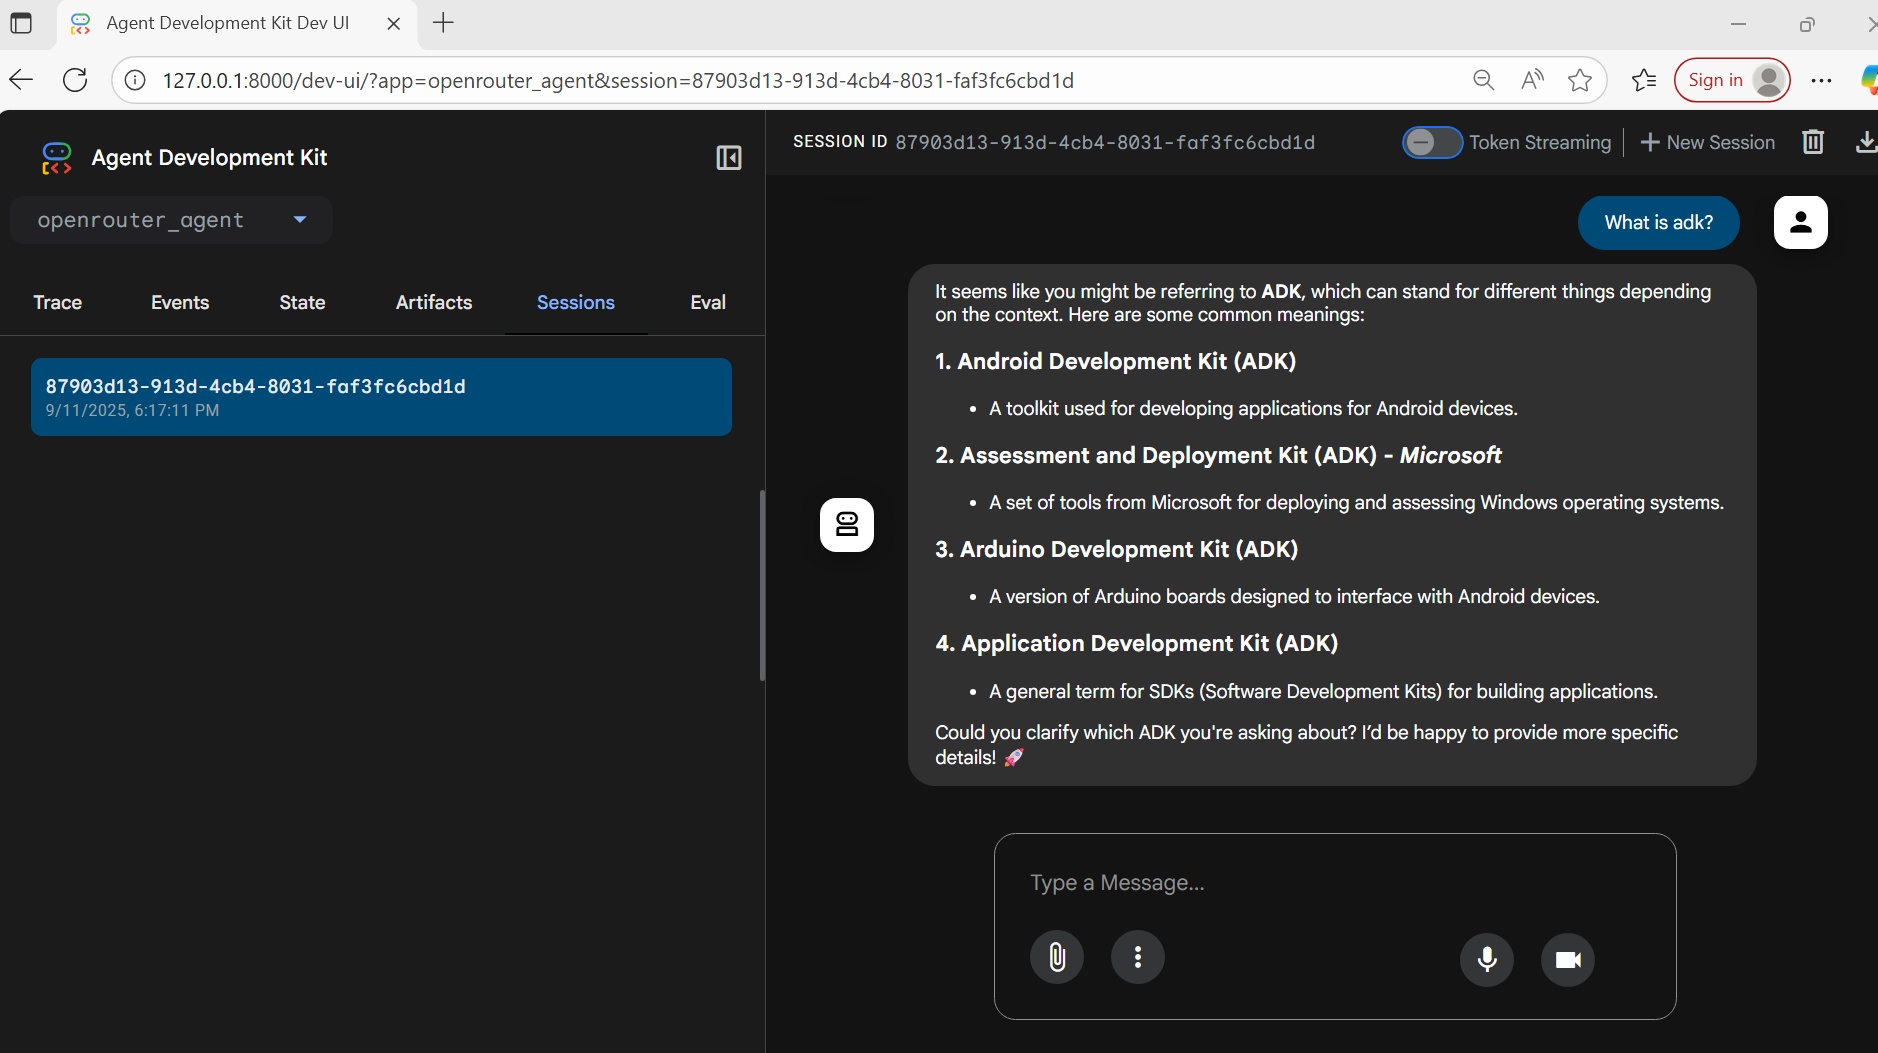

---

## Ollama Agent
```Python
from google.adk.agents import Agent
from google.adk.models.lite_llm import LiteLlm

ollama_model = LiteLlm(model='ollama_chat/llama3.2')

# It is important to set the provider ollama_chat instead of ollama. Using ollama will result in unexpected behaviors such as infinite tool call loops and ignoring previous context.


# export OLLAMA_API_BASE="http://localhost:11434"
# adk web

root_agent = Agent(
    model=ollama_model,
    name='root_agent',
    description='A helpful assistant for user questions.',
    instruction='Answer user questions to the best of your knowledge',
)
```

## `http://127.0.0.1:8000`
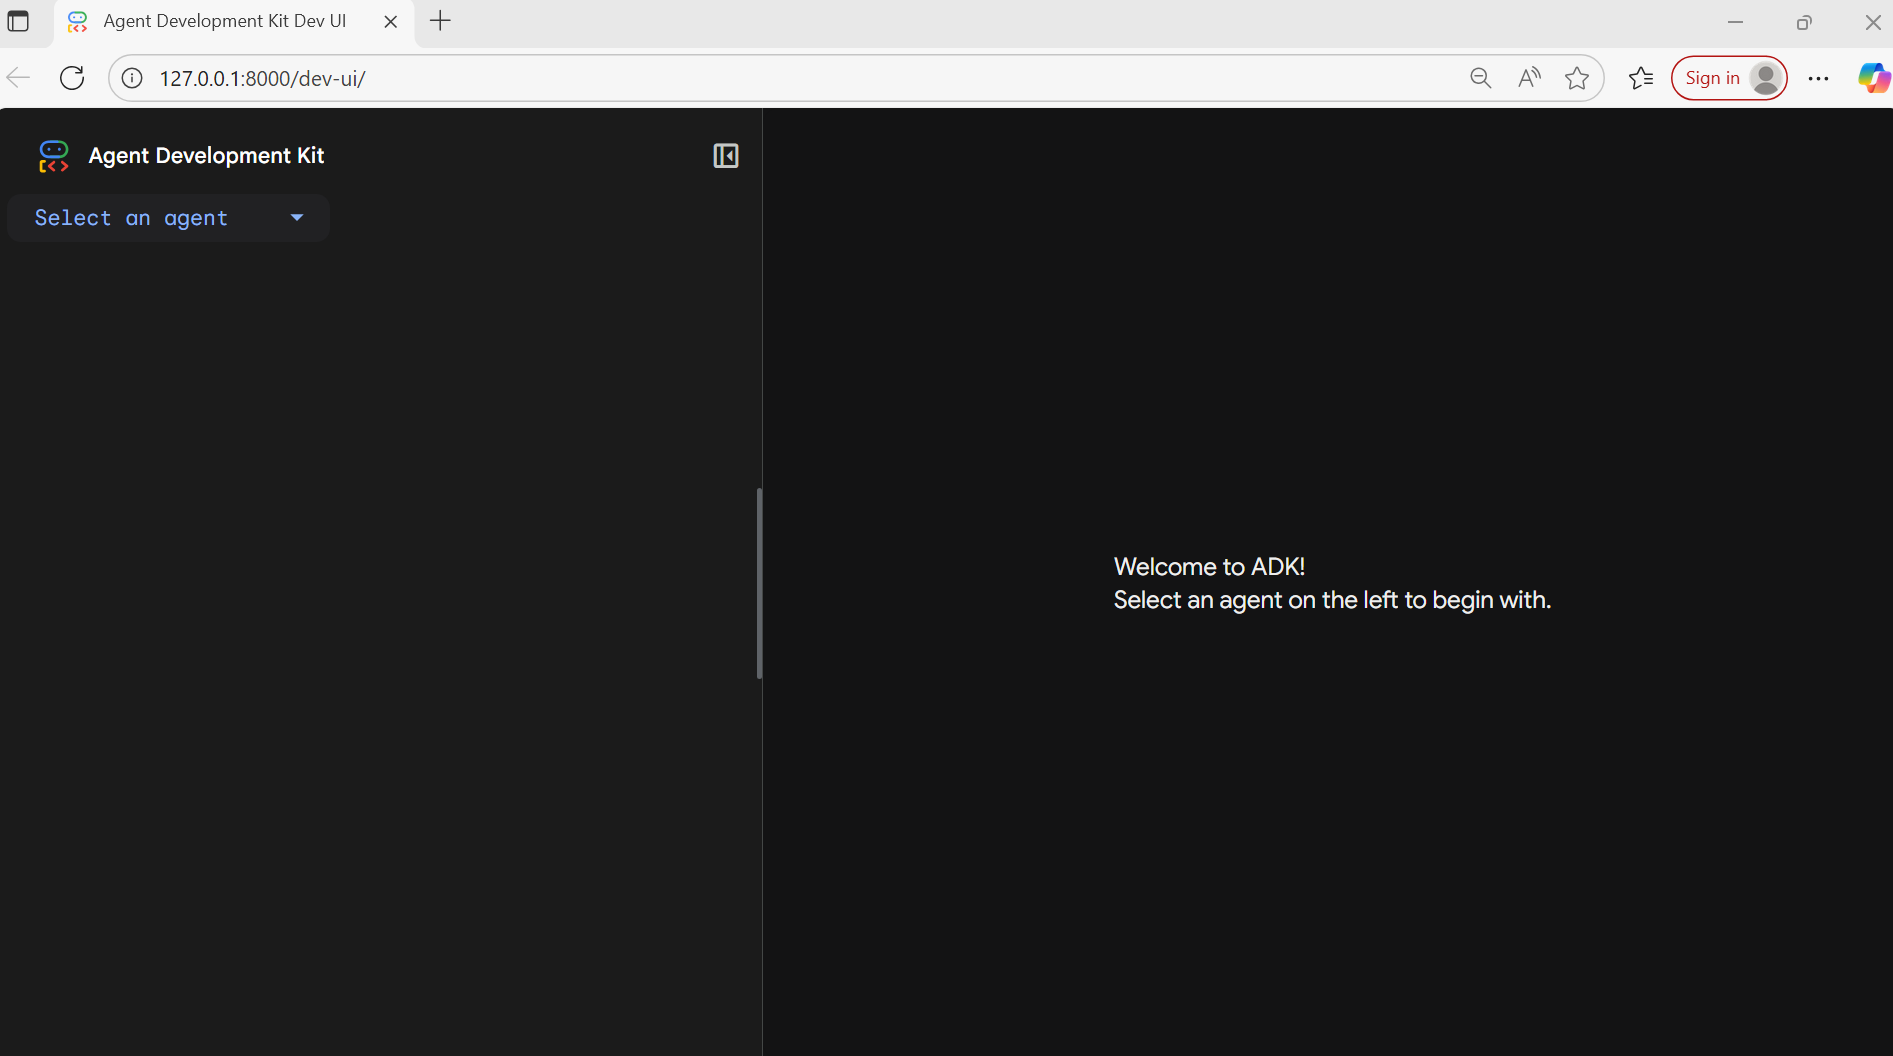 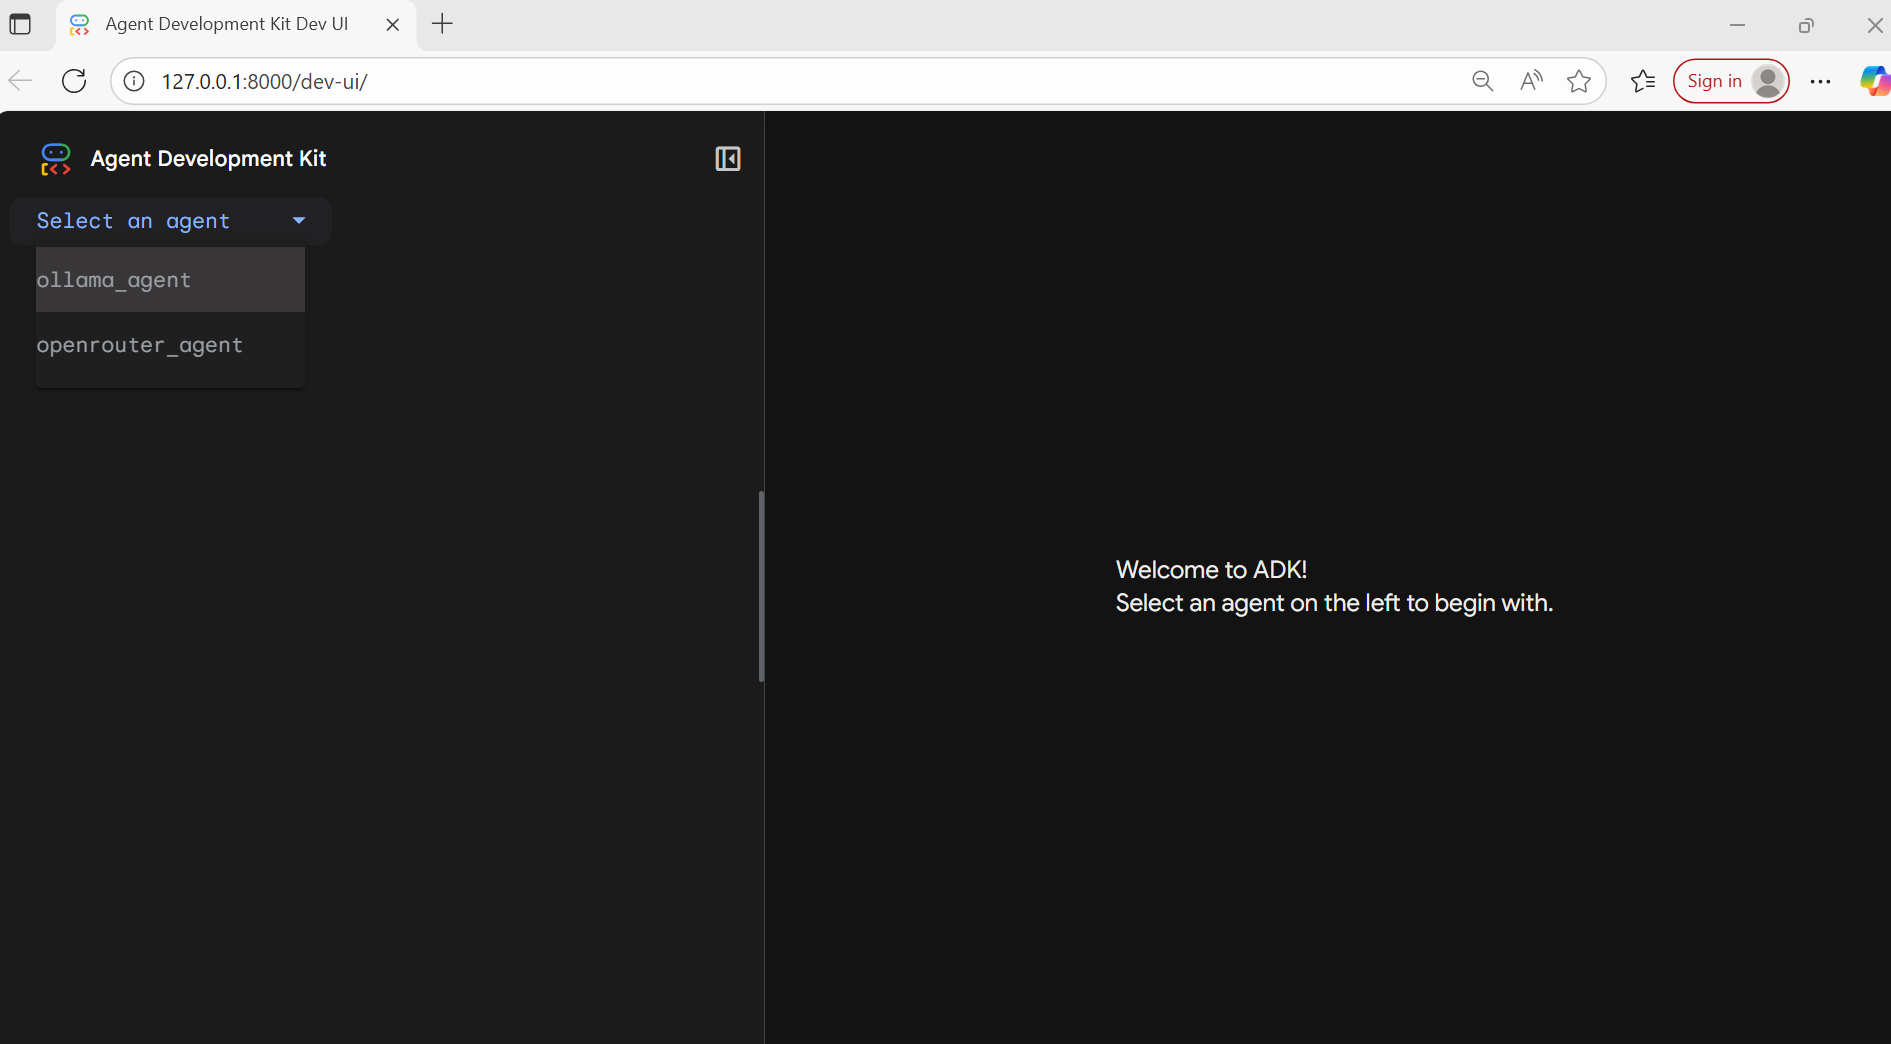
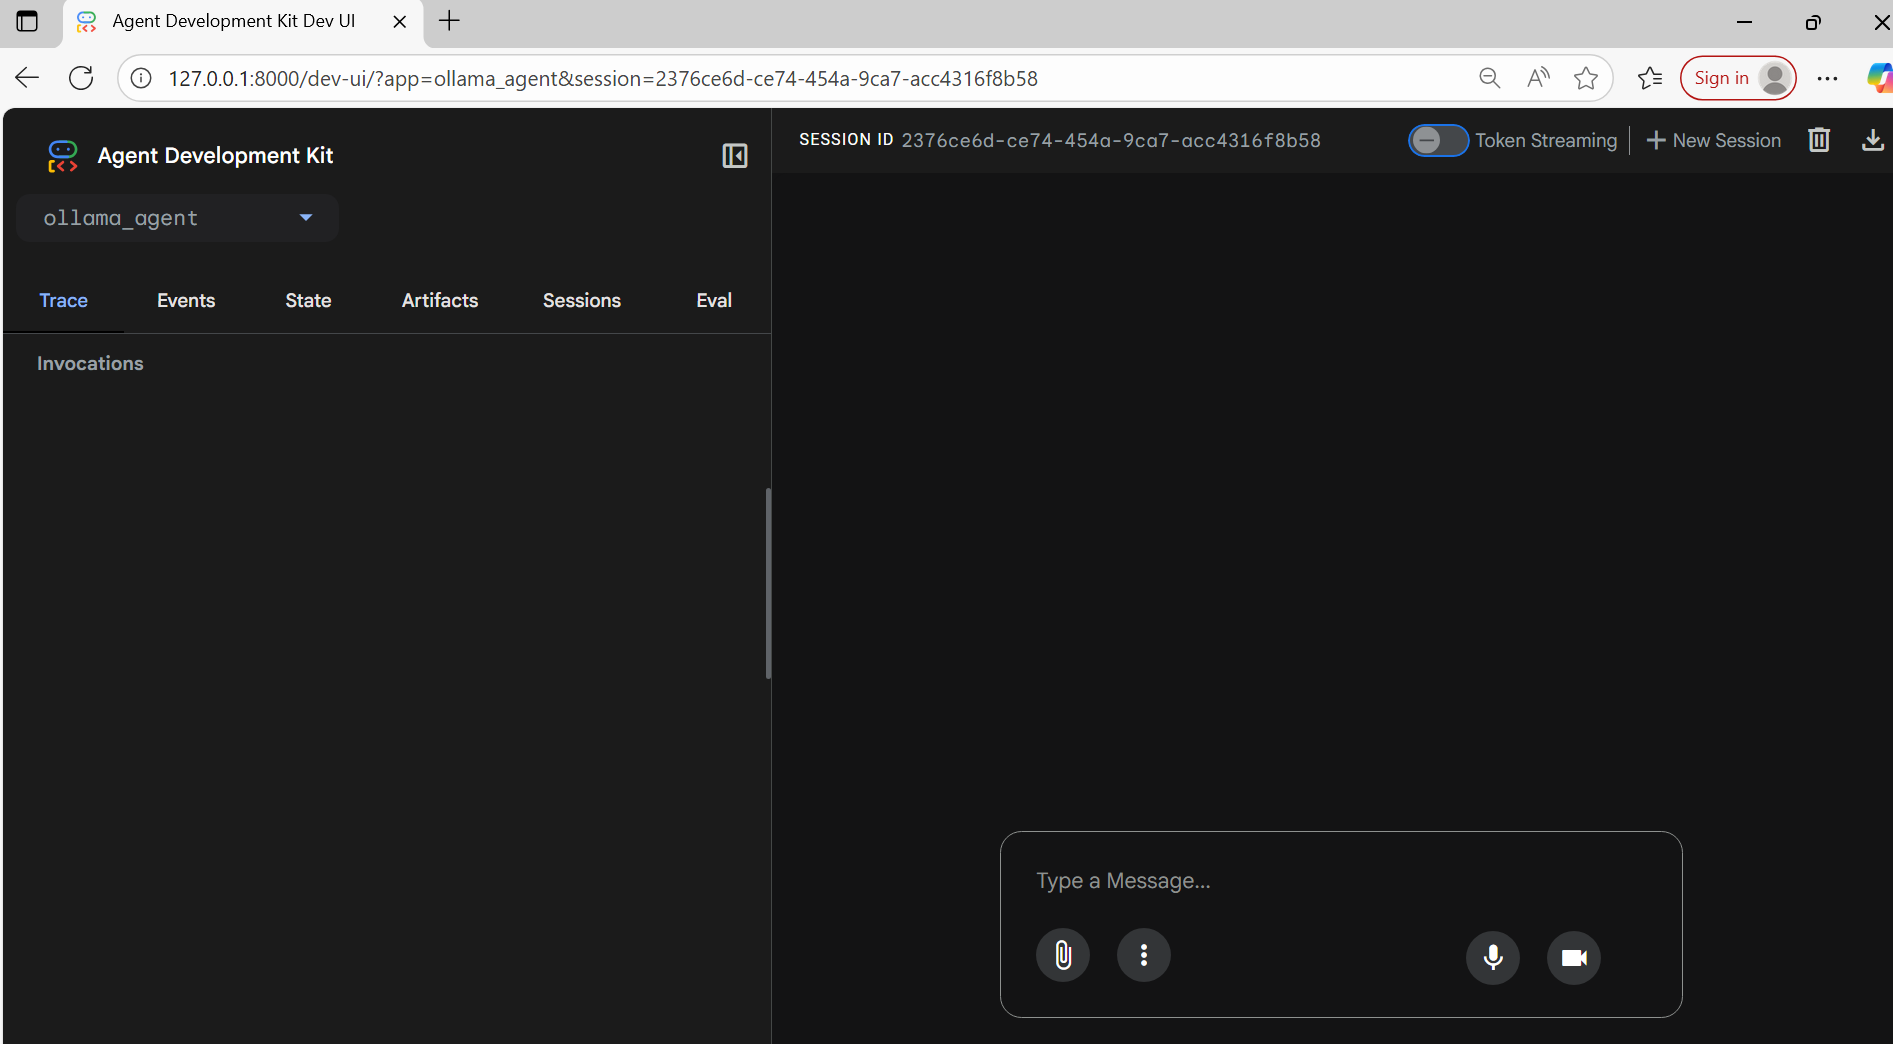 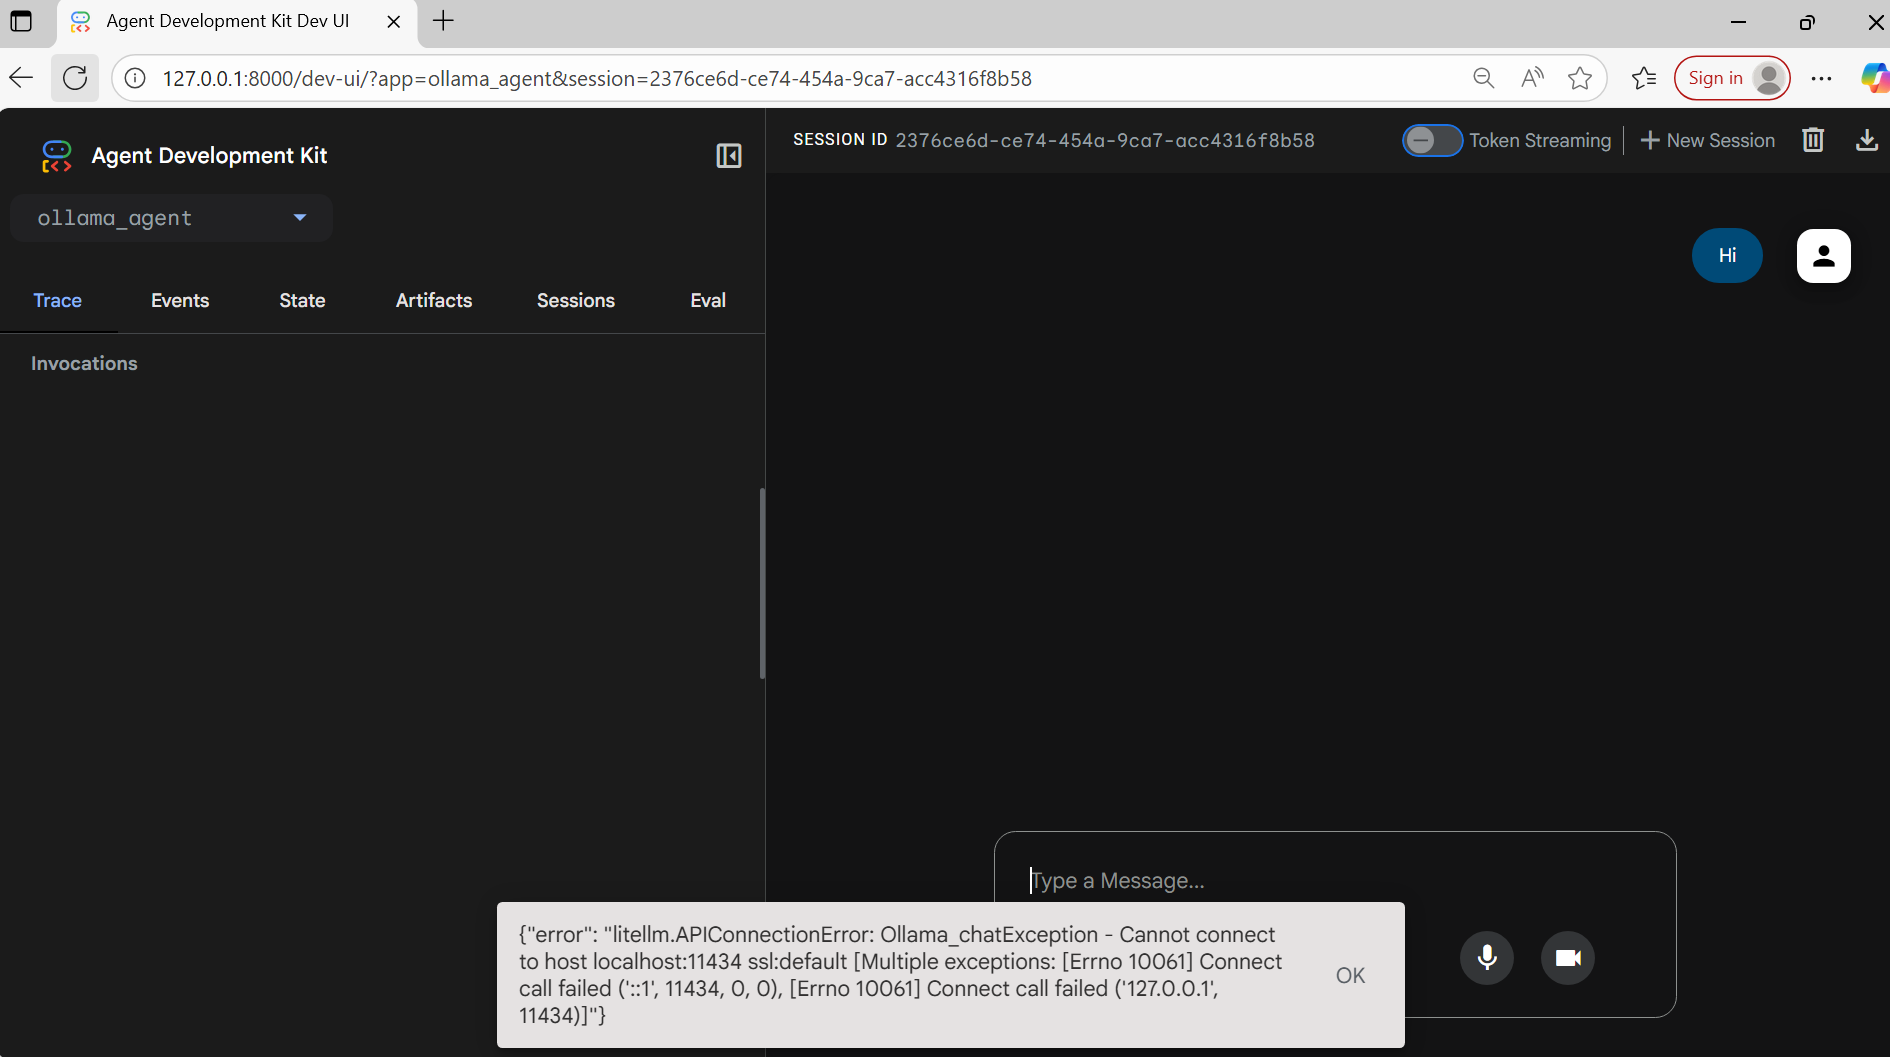

---

## OpenAI Model
```Python
from google.adk.agents import Agent
from google.adk.models.lite_llm import LiteLlm
import dotenv
dotenv.load_dotenv()
import os
from google.genai.types import GenerateContentConfig 


api_key = os.getenv('OPENAI_API_KEY')

model_openAI = LiteLlm(model="openai/gpt-4o",
                       api_key=api_key,
                       max_tokens=10, # https://docs.litellm.ai/docs/completion/input
                       )

root_agent = Agent(
    model=model_openAI,
    name='root_agent',
    description='A helpful assistant for user questions.',
    instruction='Answer user questions to the best of your knowledge',
)
```
## `http://127.0.0.1:8000`
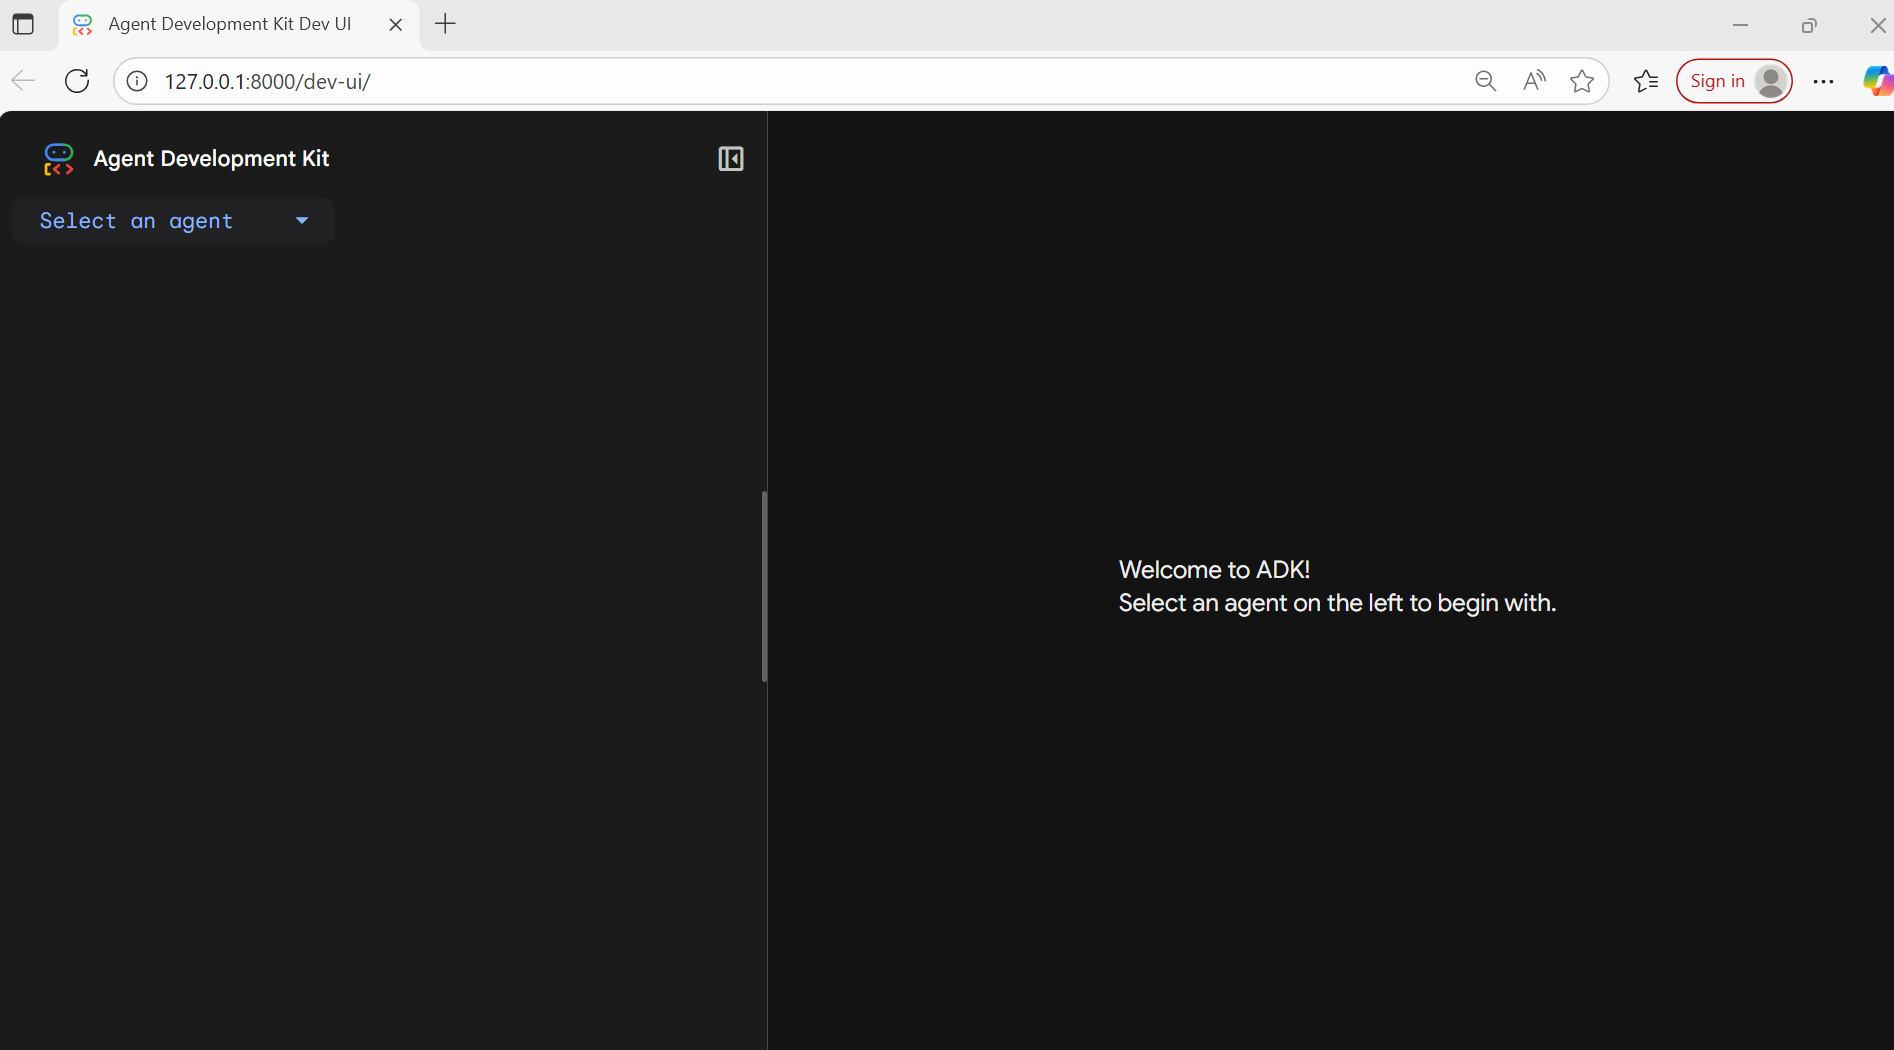 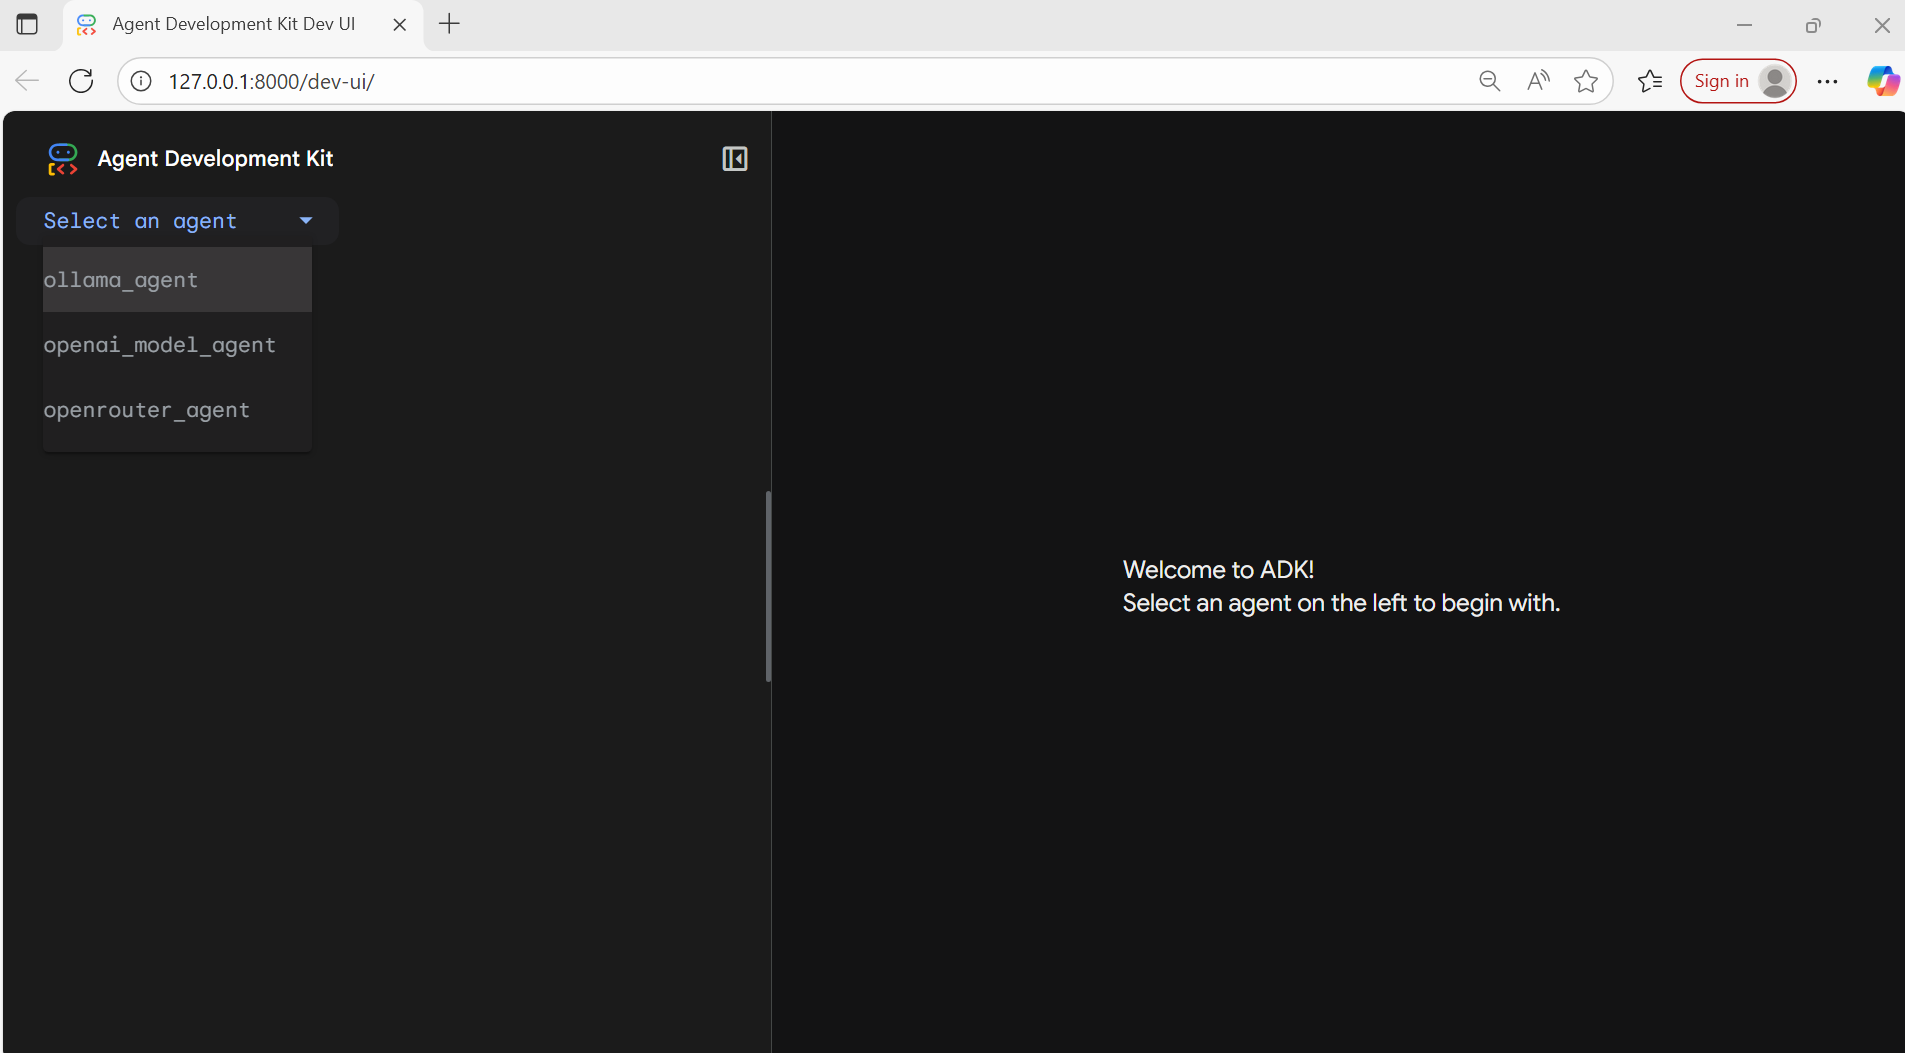
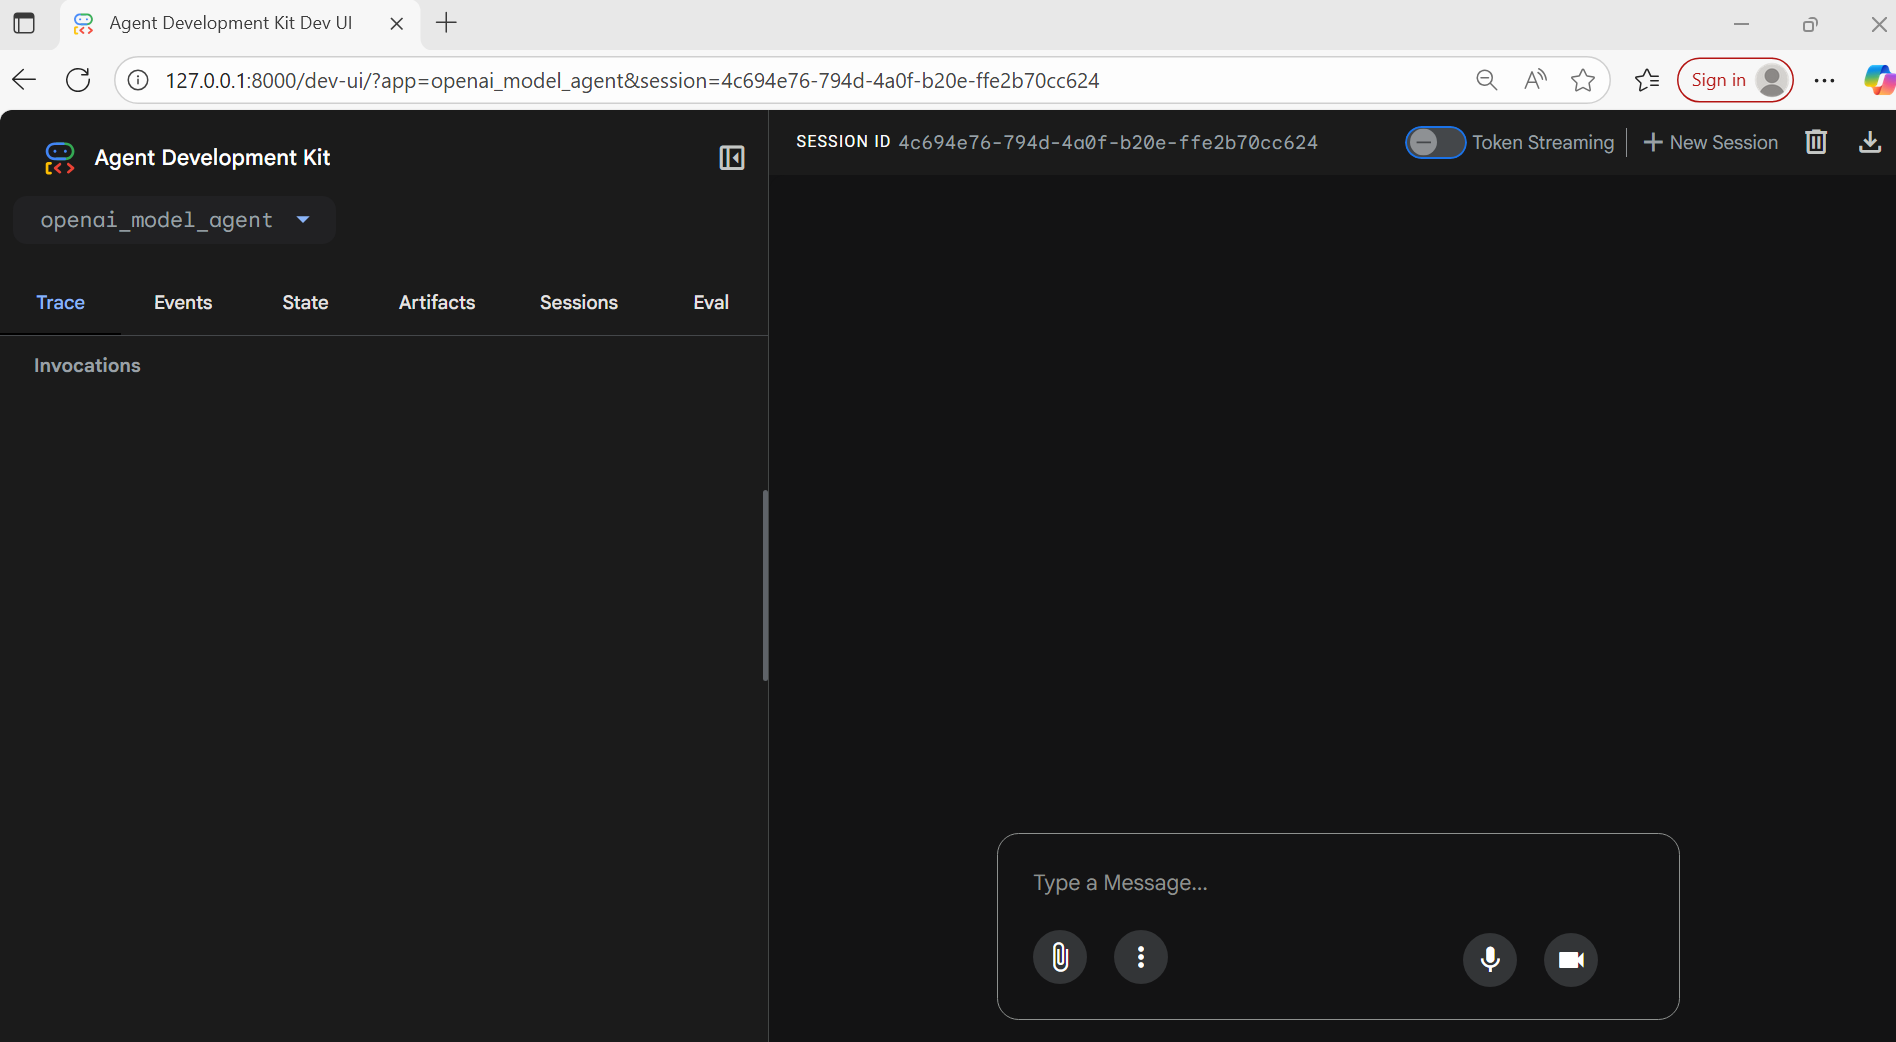 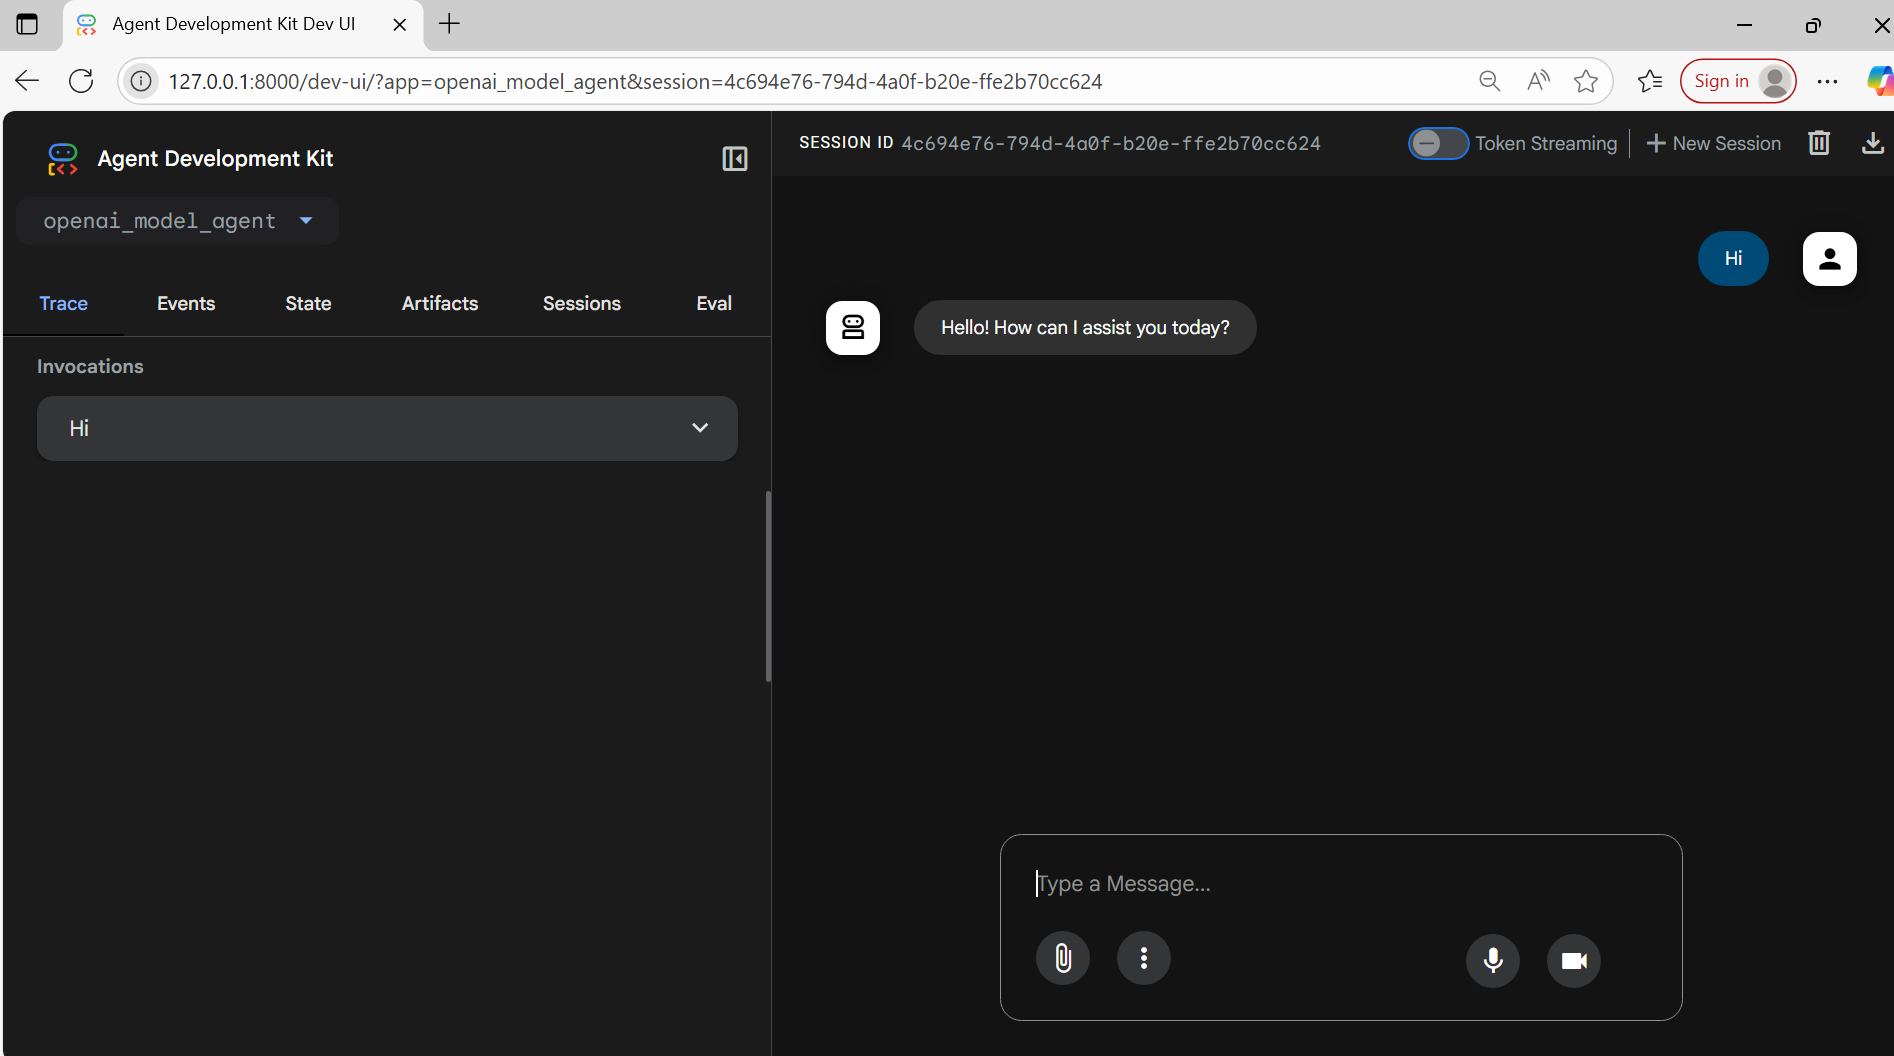
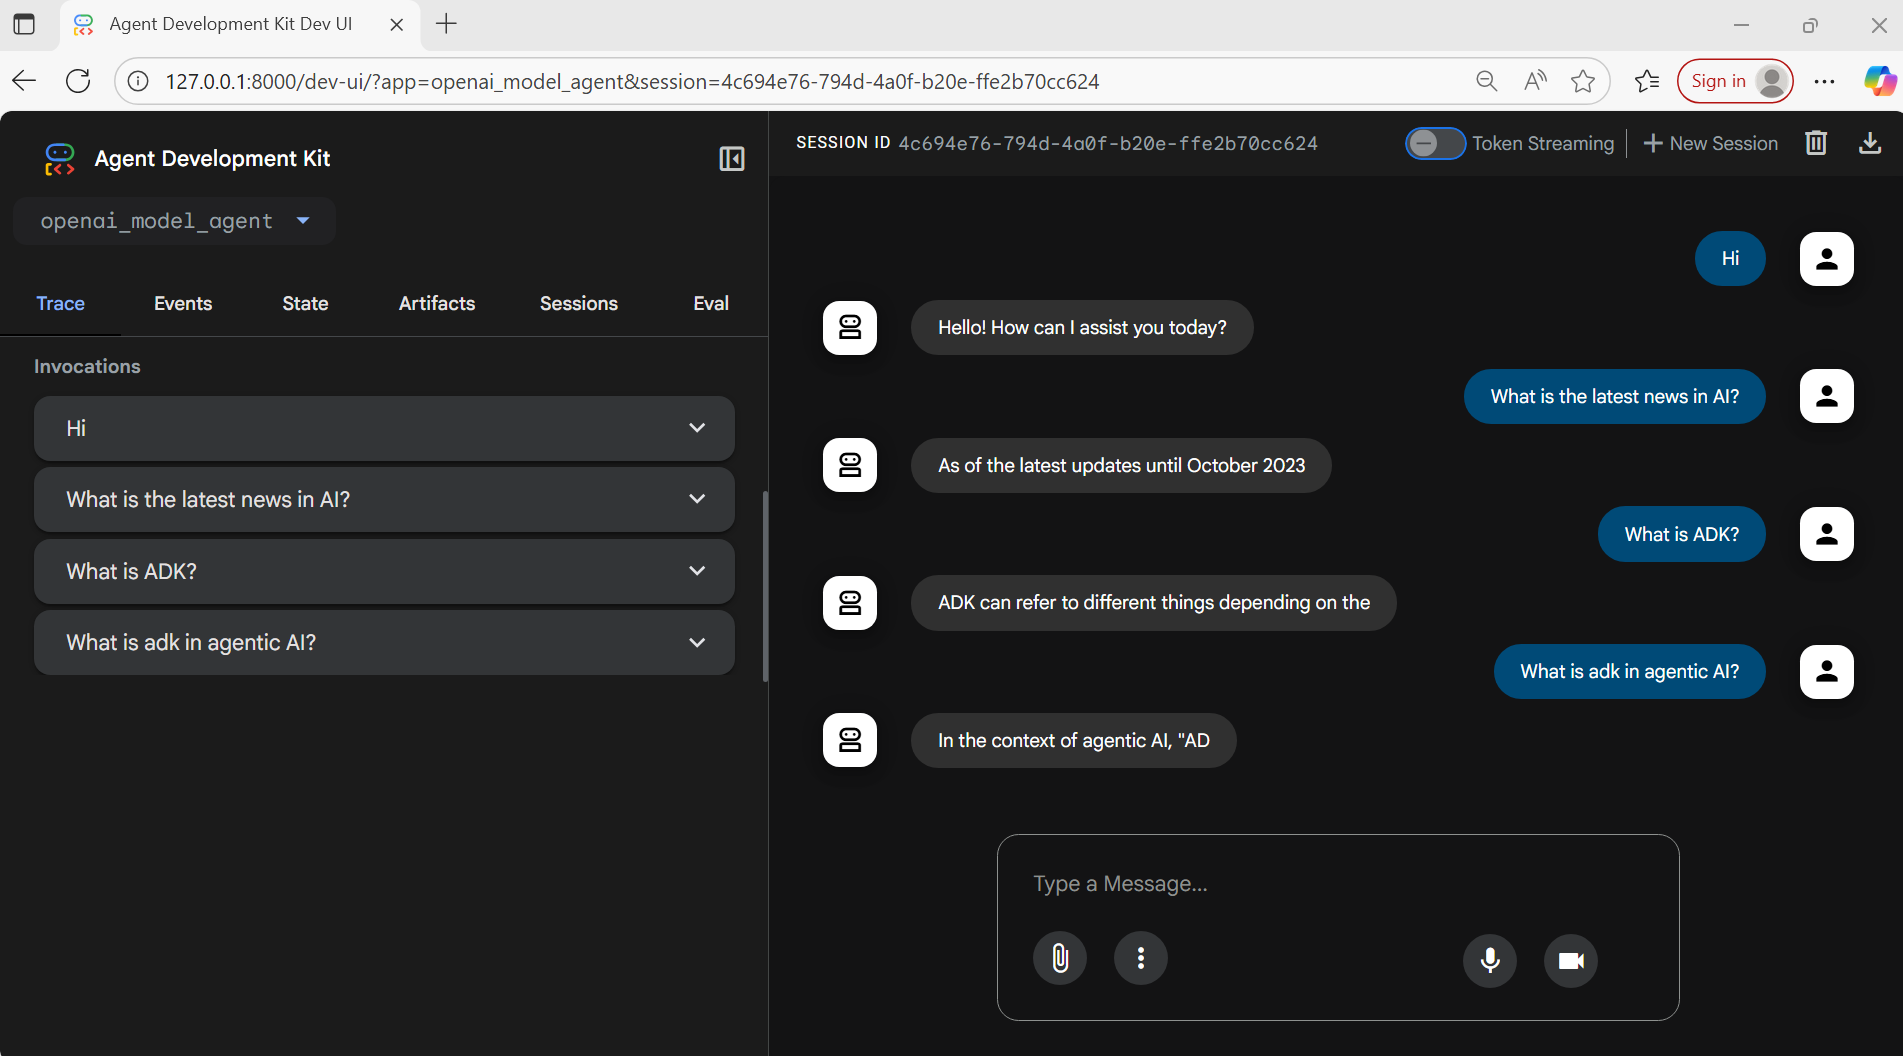 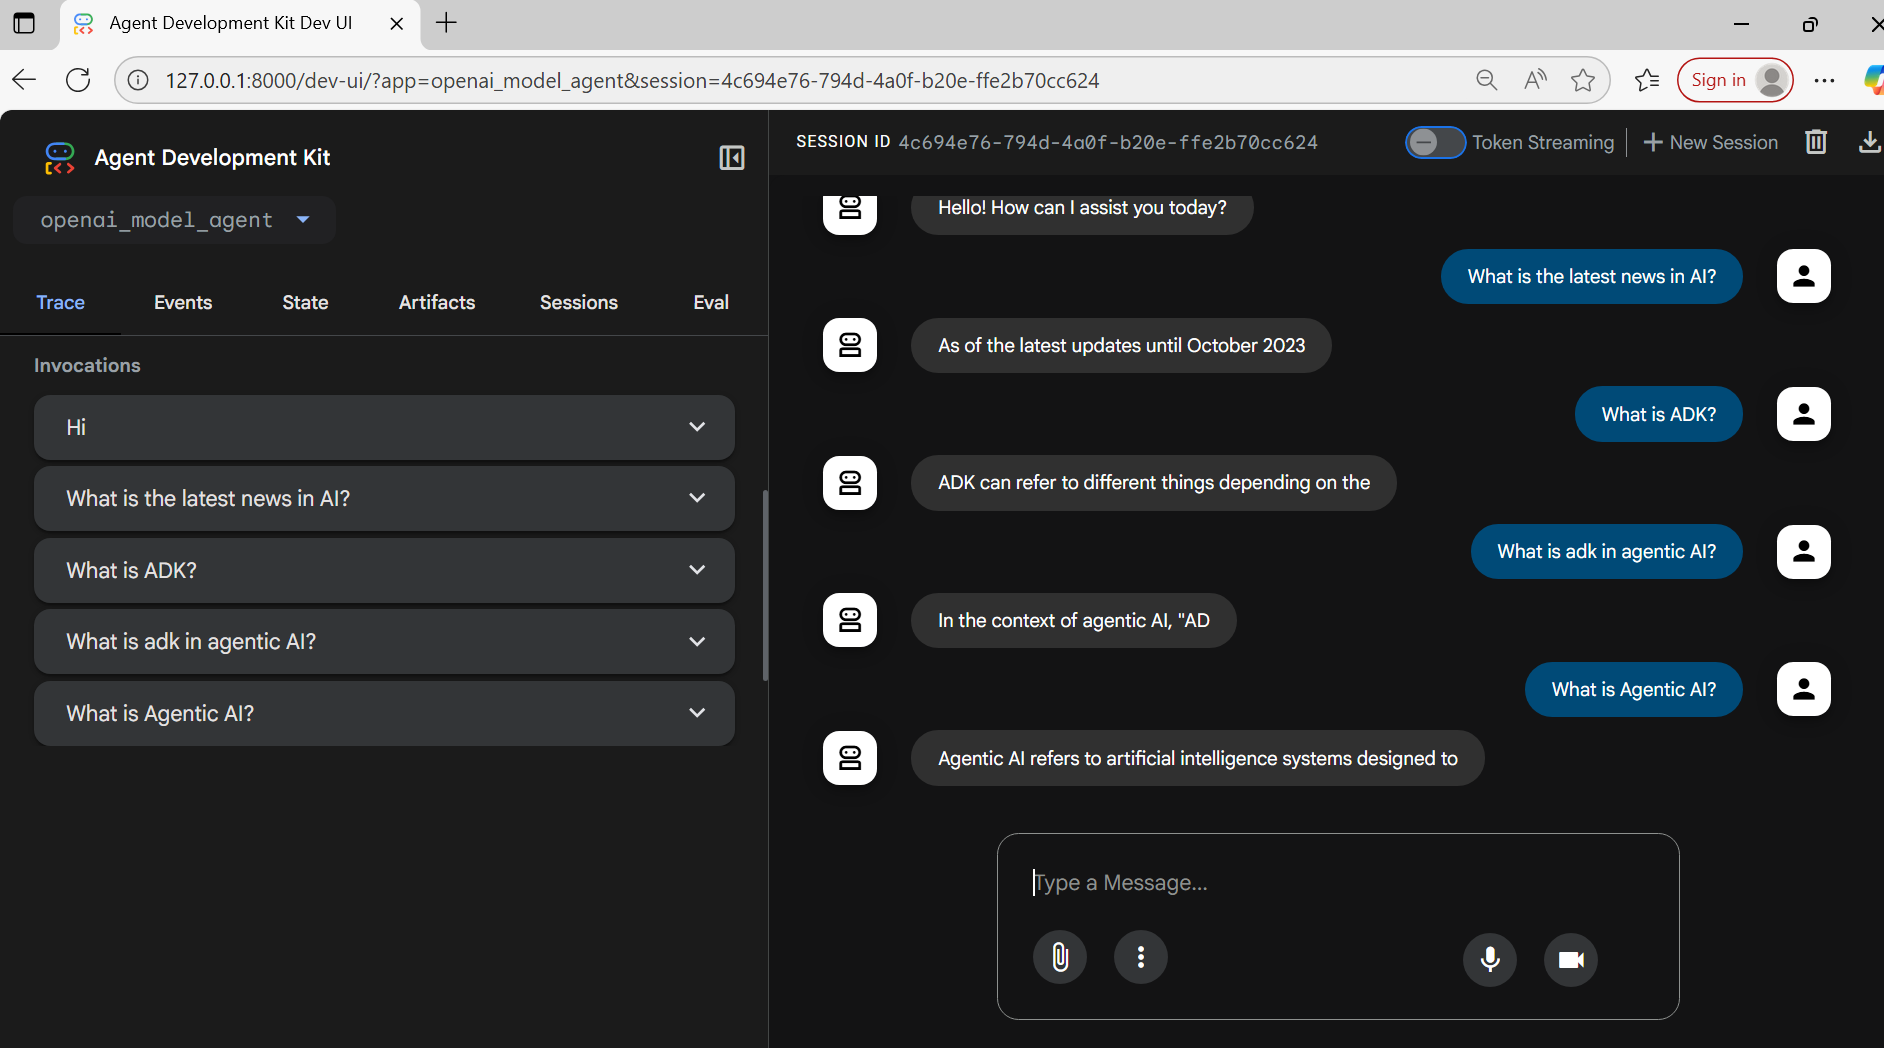
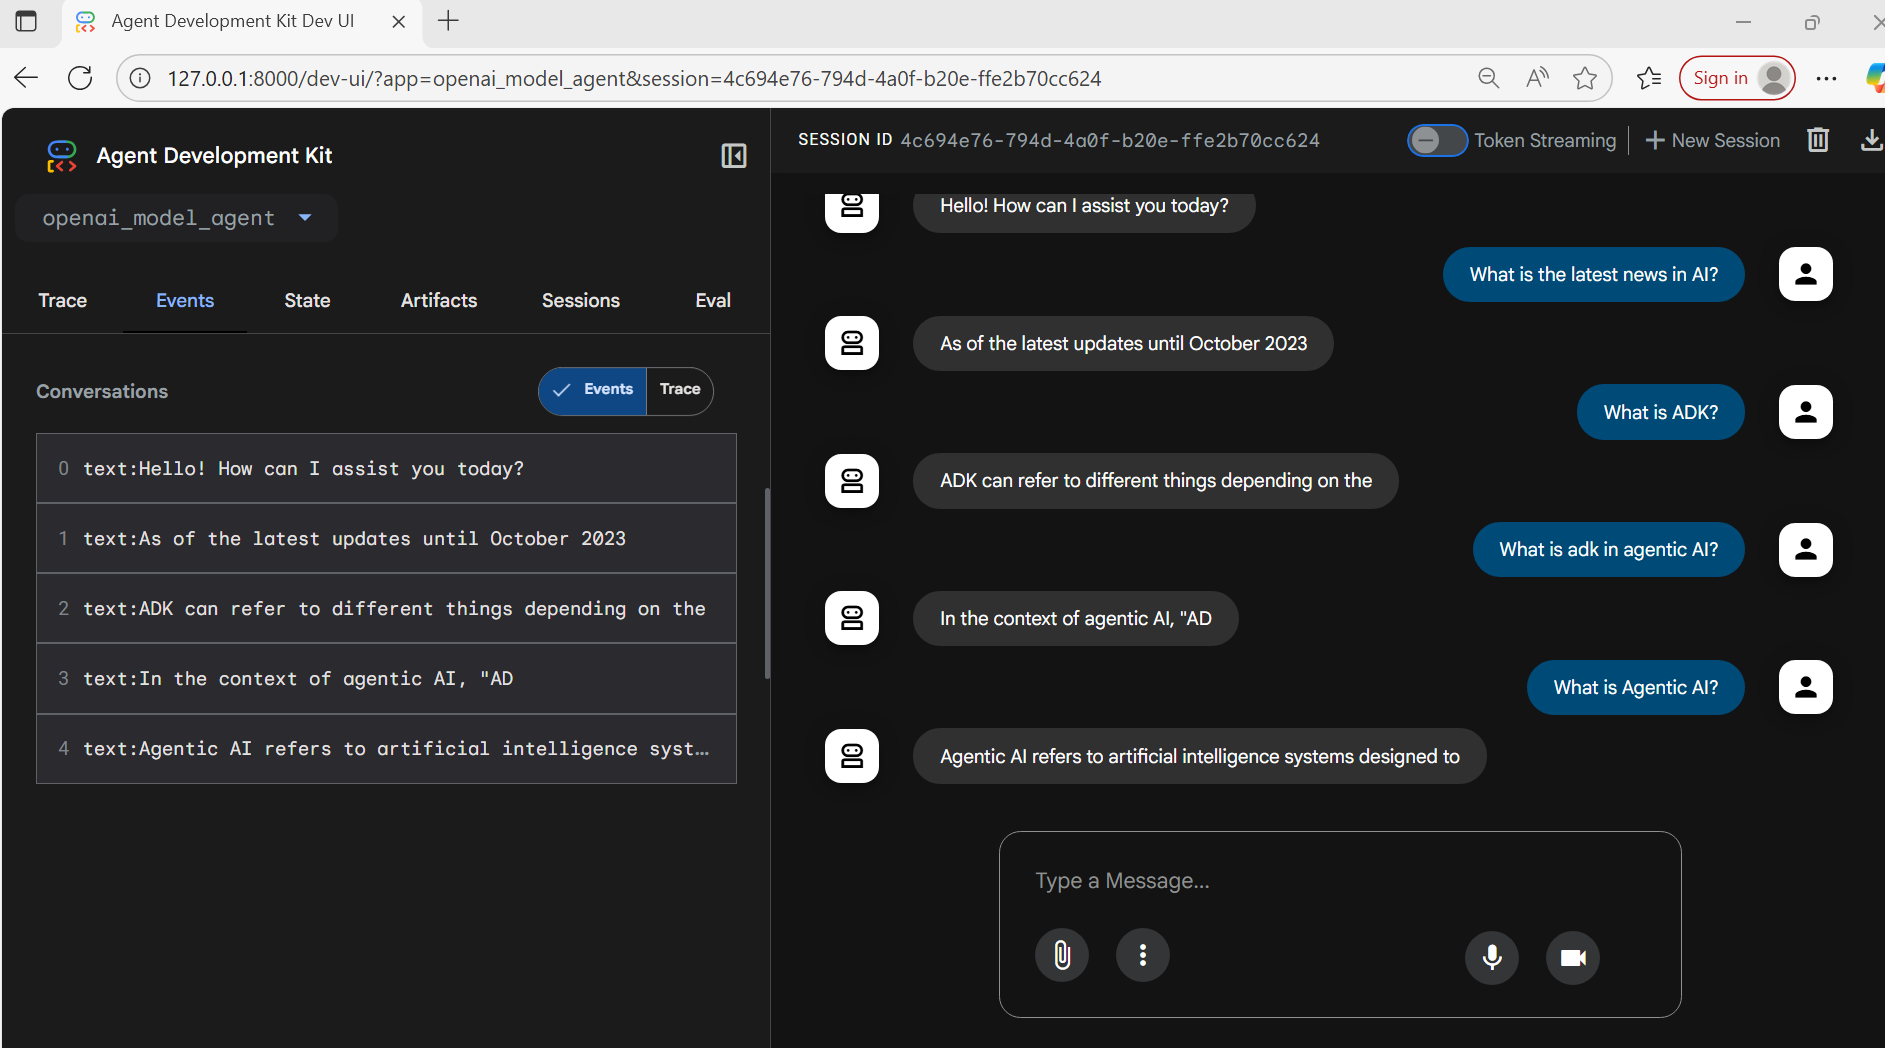 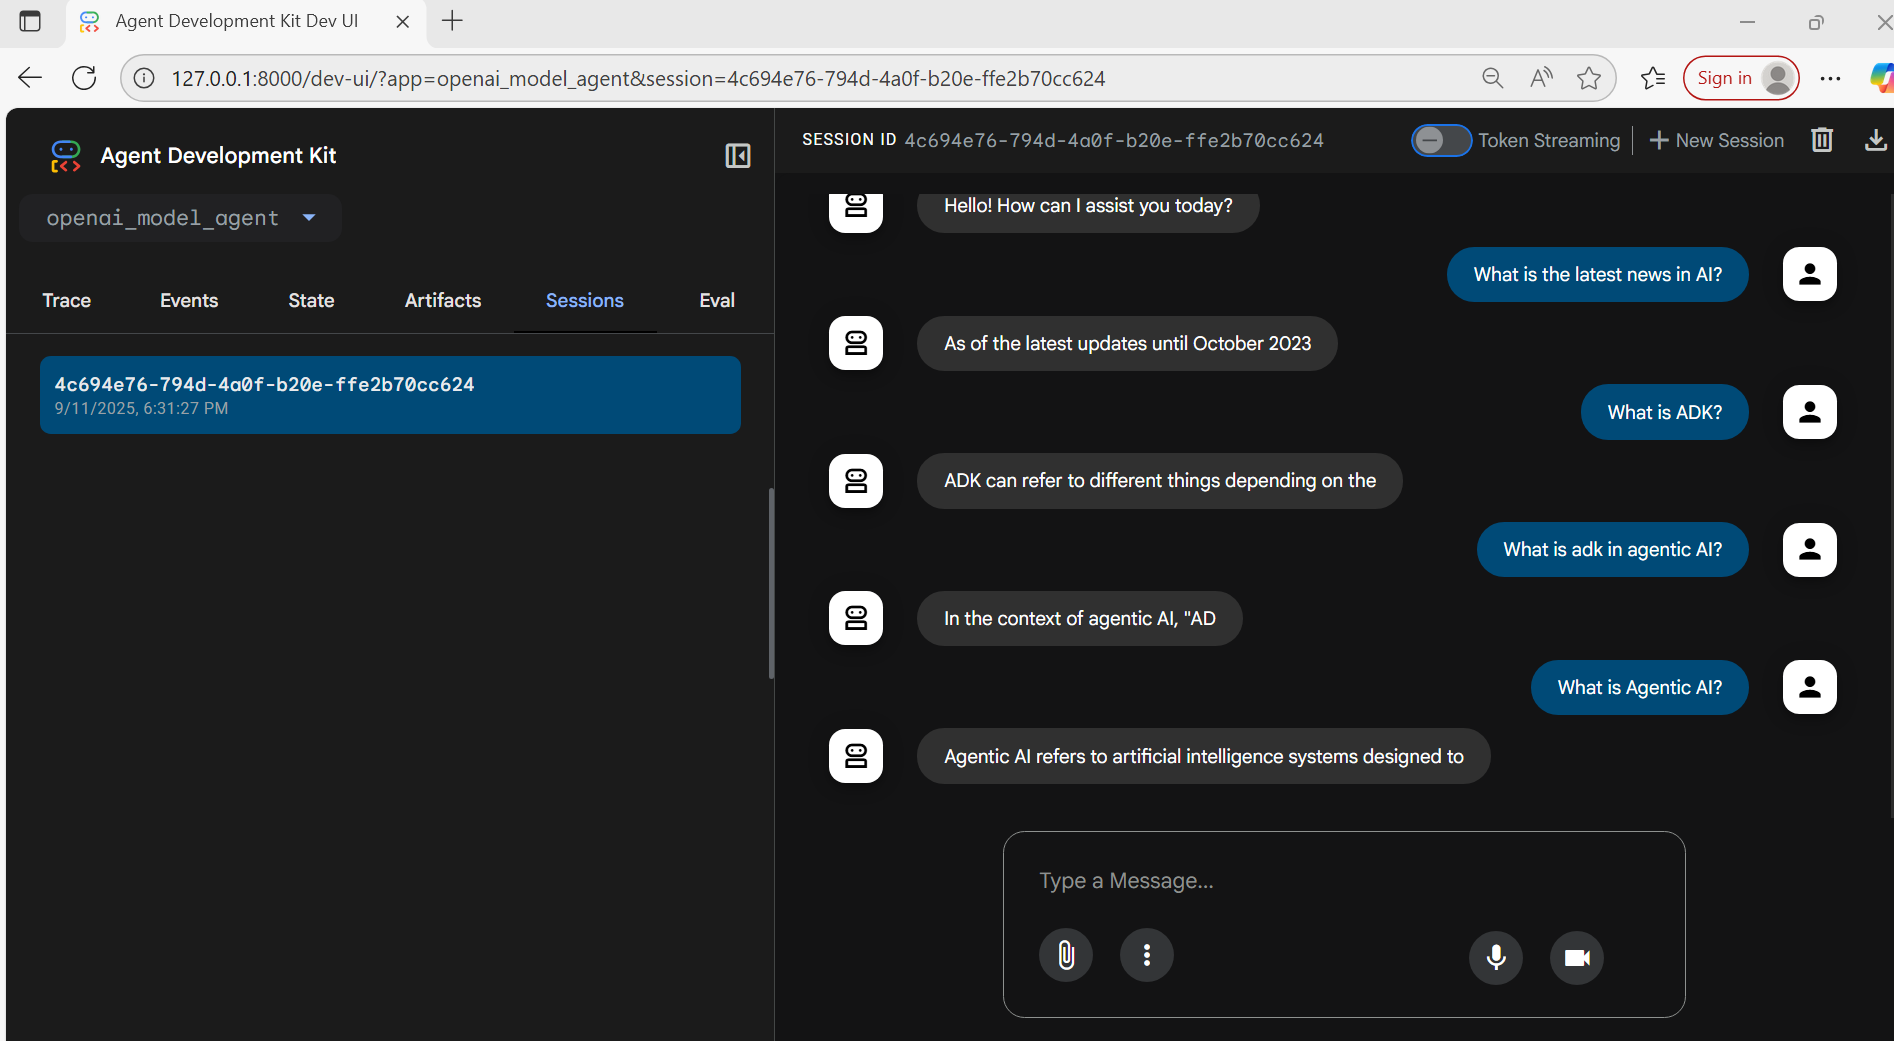

---

## Difference between `LiteLLM` and `OpenRouter`
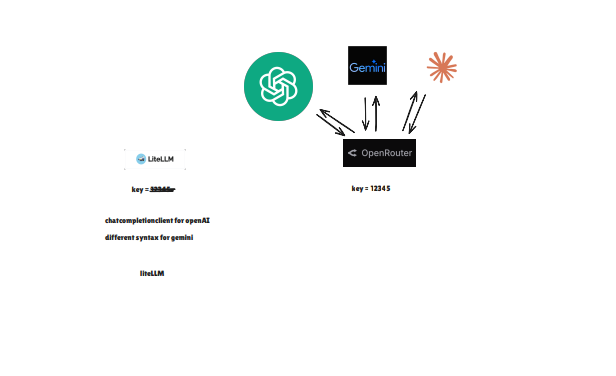

<hr>